# Intento de Golpe de Estado 23F, España 1981
## Notebook unificado — Casos de Analítica de Datos
**Equipo NotBots · Grupo B** — Máster Big Data, Universidad de Navarra (DATAI)

Sophie Kim Hong · Juan López Muñoz · David Tovar Zerda · David Martín Sastre · Alinson Ortiz Pimentel

---

Este notebook integra todos los casos del proyecto en un único flujo ejecutable de principio a fin, organizado por secciones. Todas las rutas son **relativas** respecto a la carpeta del notebook.

### Índice
0. Configuración común
1. EDA
2. Caso 1 — Cuellos de botella informativos
3. Caso 2 — Grafo de relaciones
4. Caso 3 — Análisis comparativo semántico
5. Caso 4 — Clasificación de participantes
6. Caso 5 — Momentos de incertidumbre
7. Caso 6 — Probabilidad de éxito por hora


## 0. Configuración común
Rutas, carpetas de salida y comprobación de ficheros de datos.


In [ ]:
from pathlib import Path
import os, warnings, subprocess, sys
warnings.filterwarnings('ignore')

# --- Asegurar gdown disponible ---
try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
    import gdown

# Carpeta base = donde está este notebook (ruta relativa)
BASE = Path('.').resolve()
OUTPUTS = BASE / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

# --- Ficheros grandes alojados en Google Drive ---
# (No caben en GitHub por tamaño; se descargan automáticamente la primera vez.)
# Requisito: cada fichero compartido como "Cualquier persona con el enlace (lector)".
ARCHIVOS_DRIVE = {
    '23f_scrappedDF_v02.csv': '1i9x9nrFKTRi_ptYX_2w41DKt1yxR_X4x',  # Caso 2 - grafo relaciones
    'embeddings.csv':         '1VWxGUu6LQcYxNoLjbcmkOSQXIfdu6q-t',  # Caso 1 - cuellos de botella
}

print('Descarga de ficheros desde Google Drive (si no están en local):')
for nombre, file_id in ARCHIVOS_DRIVE.items():
    if Path(nombre).exists():
        print(f'  [OK]    {nombre} ya está en local.')
    else:
        print(f'  [...]   Descargando {nombre} ...')
        try:
            gdown.download(id=file_id, output=nombre, quiet=True)
            estado = 'descargado' if Path(nombre).exists() else 'FALLÓ'
            print(f'  [{estado}] {nombre}')
        except Exception as e:
            print(f'  [ERROR] {nombre}: {e}')

# --- Comprobación final de todos los ficheros de datos esperados ---
ESPERADOS = {
    '23f_scrappedDF.csv'       : 'Corpus principal (EDA y varios casos)',
    '23f_scrappedDF_v02.csv'   : 'Caso 2 - grafo relaciones',
    'embeddings.csv'           : 'Caso 1 - cuellos de botella',
    '23f_frases_etiquetas4.csv': 'Caso 4 - clasificacion',
}
print('\nComprobación de ficheros de datos:')
for f_, uso in ESPERADOS.items():
    estado = 'OK   ' if Path(f_).exists() else 'FALTA'
    print(f'  [{estado}] {f_:<28} -> {uso}')
print('\nCarpeta de salidas:', OUTPUTS)

---
## Análisis Exploratorio de Datos (EDA)
Análisis inicial del corpus de documentos desclasificados del 23F.


# Análisis Exploratorio Exhaustivo: Dataset 23F Documentos

**Dataset:** 23f_scrappedDF.csv  
**Objetivo:** Entender en profundidad la estructura, calidad y potencial del dataset de documentos históricos sobre el 23F (España, 1982)

---

## Índice
1. [Importaciones y Carga](#1-importaciones)
2. [Visión General](#2-visión-general)
3. [Calidad de Datos](#3-calidad)
4. [Análisis Estadístico](#4-estadístico)
5. [Distribuciones](#5-distribuciones)
6. [Anomalías y Outliers](#6-anomalías)
7. [Limitaciones y Potencial](#7-limitaciones)
8. [Conclusiones](#8-conclusiones)

## 1. Importaciones y Carga del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Cargar dataset
df = pd.read_csv('23f_scrappedDF.csv')

print("✅ Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

## 2. Visión General del Dataset

### 2.1 Primeras filas y estructura

In [ ]:
# Mostrar primeras filas
print("PRIMERAS 3 FILAS DEL DATASET:")
print("="*80)
  
for col in df.columns:
    print(f"\n📄 {col.upper()}:")
    
    # 1. Obtenemos el primer elemento
    primer_valor = df[col].iloc[0]
    
    # 2. Lo convertimos a string de forma segura y lo recortamos
    texto_recortado = str(primer_valor)[:150]
    
    print(f"   {texto_recortado}...")

print("\n\nINFORMACIÓN GENERAL:")
print("="*80)

print("\n\nINFORMACIÓN GENERAL:")
print("="*80)
print(f"Columnas: {', '.join(df.columns.tolist())}")
print(f"\nTipos de datos:")
print(df.dtypes)

## 3. Análisis de Calidad de Datos

### 3.1 Valores Nulos y Completitud

In [ ]:
# Análisis de valores nulos
null_analysis = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores válidos': df.notnull().sum()
})

print("📊 ANÁLISIS DE VALORES NULOS:")
print("="*80)
print(null_analysis.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
null_counts = df.isnull().sum()
colors = ['#2ecc71' if x == 0 else '#e74c3c' for x in null_counts]
bars = ax.barh(null_counts.index, null_counts.values, color=colors)
ax.set_xlabel('Número de valores nulos')
ax.set_title('Valores Nulos por Columna', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(null_counts.values) + 5 if max(null_counts.values) > 0 else 1)

# Añadir etiquetas
for i, (idx, val) in enumerate(null_counts.items()):
    ax.text(val + 0.1, i, f'{val} (0%)', va='center')

plt.tight_layout()
plt.show()

print(f"\n✅ CONCLUSIÓN: {len(null_analysis[null_analysis['Nulos'] == 0])}/{len(null_analysis)} columnas sin valores nulos")

### 3.2 Duplicados

In [ ]:
print("🔍 ANÁLISIS DE DUPLICADOS:")
print("="*80)

# Duplicados totales
duplicados_exactos = df.duplicated().sum()
print(f"\nFilas duplicadas exactas: {duplicados_exactos} ({duplicados_exactos/len(df)*100:.2f}%)")

# Duplicados por columna
duplicate_analysis = pd.DataFrame({
    'Columna': df.columns,
    'Duplicados': [df[col].duplicated().sum() for col in df.columns],
    '% Duplicados': [(df[col].duplicated().sum() / len(df) * 100) for col in df.columns]
})

print("\nDuplicados por columna:")
print(duplicate_analysis.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
dup_counts = [df[col].duplicated().sum() for col in df.columns]
colors = ['#2ecc71' if x == 0 else '#e74c3c' for x in dup_counts]
ax.barh(df.columns, dup_counts, color=colors)
ax.set_xlabel('Número de duplicados')
ax.set_title('Duplicados por Columna', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(dup_counts) + 1 if max(dup_counts) > 0 else 1)
plt.tight_layout()
plt.show()

print(f"\n✅ CONCLUSIÓN: Dataset limpio de duplicados")

## 4. Análisis Estadístico Detallado

### 4.1 Variables Numéricas

In [ ]:
# Añadir columnas de longitud
df['title_length'] = df['title'].str.len()
df['summary_length'] = df['summary'].str.len()
df['transcript_length'] = df['transcript'].str.len()
df['tags_length'] = df['tags'].str.len()
df['chars_per_page'] = df['transcript_length'] / df['pages']

print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

numeric_cols = ['pages', 'title_length', 'summary_length', 'transcript_length', 'chars_per_page']
stats_df = df[numeric_cols].describe().round(2)
print(stats_df)

print("\n\n📈 ESTADÍSTICAS ADICIONALES:")
print("="*80)

for col in numeric_cols:
    print(f"\n{col.upper()}:")
    print(f"  • Skewness (asimetría): {stats.skew(df[col]):.3f}")
    print(f"  • Kurtosis (curtosis): {stats.kurtosis(df[col]):.3f}")
    print(f"  • CV (Coef. Variación): {df[col].std() / df[col].mean():.3f}")

### 4.2 Variables de Texto

In [ ]:
print("📝 ANÁLISIS DE VARIABLES DE TEXTO")
print("="*80)

print("\n🔤 TÍTULOS:")
print(f"  • Total: {df['title'].notna().sum()} títulos únicos")
print(f"  • Longitud media: {df['title_length'].mean():.0f} caracteres")
print(f"  • Longitud mín/máx: {df['title_length'].min()}/{df['title_length'].max()}")
print(f"  • Desv. estándar: {df['title_length'].std():.0f}")

print("\n📄 RESÚMENES:")
print(f"  • Total: {df['summary'].notna().sum()} resúmenes")
print(f"  • Longitud: {df['summary_length'].unique()[0]} caracteres (UNIFORME ⚠️)")
print(f"  • Resúmenes truncados en '...': {(df['summary'].str.endswith('...')).sum()}")

print("\n📋 TRANSCRIPCIONES:")
print(f"  • Total: {df['transcript'].notna().sum()} transcripciones")
print(f"  • Longitud media: {df['transcript_length'].mean():.0f} caracteres")
print(f"  • Longitud mín/máx: {df['transcript_length'].min()}/{df['transcript_length'].max()}")
print(f"  • Desv. estándar: {df['transcript_length'].std():.0f}")

print("\n🏷️ TAGS:")
print(f"  • Total: {df['tags'].notna().sum()} documentos con tags")
print(f"  • Longitud media: {df['tags_length'].mean():.0f} caracteres")

## 5. Análisis de Distribuciones

### 5.1 Distribución de Páginas

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(df['pages'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Número de páginas')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Páginas (Histograma)', fontweight='bold')
axes[0, 0].axvline(df['pages'].mean(), color='red', linestyle='--', label=f'Media: {df["pages"].mean():.1f}')
axes[0, 0].axvline(df['pages'].median(), color='green', linestyle='--', label=f'Mediana: {df["pages"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot
axes[0, 1].boxplot(df['pages'], vert=True)
axes[0, 1].set_ylabel('Número de páginas')
axes[0, 1].set_title('Distribución de Páginas (Box Plot)', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Q-Q plot
stats.probplot(df['pages'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normalidad)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Distribución logarítmica
axes[1, 1].hist(np.log1p(df['pages']), bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Log(Páginas + 1)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Páginas (Escala Log)', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Test de normalidad
stat, p_value = stats.shapiro(df['pages'])
print(f"\n📊 TEST DE NORMALIDAD (Shapiro-Wilk):")
print(f"  • p-value: {p_value:.6f}")
print(f"  • Conclusión: {'❌ NO es normal' if p_value < 0.05 else '✅ Es normal'} (α=0.05)")

### 5.2 Distribuciones de Longitudes de Texto

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Títulos
axes[0, 0].hist(df['title_length'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Caracteres')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución: Longitud de Títulos', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Resúmenes
axes[0, 1].bar(['Summary'], [df['summary_length'].unique()[0]], color='#1abc9c', alpha=0.7, width=0.3)
axes[0, 1].set_ylabel('Caracteres')
axes[0, 1].set_title('Longitud de Resúmenes (UNIFORME)', fontweight='bold')
axes[0, 1].set_ylim(0, 350)
axes[0, 1].text(0, df['summary_length'].unique()[0] + 10, '303', ha='center', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Transcripciones
axes[1, 0].hist(df['transcript_length'], bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Caracteres')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución: Longitud de Transcripciones', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Transcripciones (log)
axes[1, 1].hist(np.log1p(df['transcript_length']), bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Log(Caracteres + 1)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución: Longitud de Transcripciones (Log)', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis de Anomalías y Outliers

### 6.1 Detección de Outliers

In [ ]:
print("🔍 DETECCIÓN DE OUTLIERS (IQR)")
print("="*80)

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound), lower_bound, upper_bound

# Detectar outliers en PAGES
outliers, lower, upper = detect_outliers_iqr(df['pages'])
outlier_indices = df[outliers].index

print(f"\n📊 PÁGINAS:")
print(f"  • Límites: [{lower:.2f}, {upper:.2f}]")
print(f"  • Outliers detectados: {outliers.sum()} ({outliers.sum()/len(df)*100:.1f}%)")

if outliers.sum() > 0:
    print(f"\n  Top 5 outliers (más páginas):")
    outlier_docs = df[outliers].nlargest(5, 'pages')[['title', 'pages', 'transcript_length']]
    for idx, row in outlier_docs.iterrows():
        print(f"    • {row['pages']:3.0f} págs: {row['title'][:60]}...")

# Detectar outliers en TRANSCRIPT_LENGTH
outliers_trans, lower_t, upper_t = detect_outliers_iqr(df['transcript_length'])
print(f"\n📋 TRANSCRIPT LENGTH:")
print(f"  • Límites: [{lower_t:.0f}, {upper_t:.0f}]")
print(f"  • Outliers detectados: {outliers_trans.sum()} ({outliers_trans.sum()/len(df)*100:.1f}%)")

# Detectar outliers en CHARS_PER_PAGE
outliers_cpp, lower_cpp, upper_cpp = detect_outliers_iqr(df['chars_per_page'])
print(f"\n📄 CARACTERES POR PÁGINA:")
print(f"  • Límites: [{lower_cpp:.0f}, {upper_cpp:.0f}]")
print(f"  • Outliers detectados: {outliers_cpp.sum()} ({outliers_cpp.sum()/len(df)*100:.1f}%)")
print(f"  • Conclusión: ✅ Distribución consistente (sin anomalías)")

### 6.2 Análisis de Correlaciones

In [ ]:
# Matriz de correlación
numeric_features = ['pages', 'title_length', 'summary_length', 'transcript_length', 'chars_per_page']
correlation_matrix = df[numeric_features].corr()

print("📊 MATRIZ DE CORRELACIÓN:")
print("="*80)
print(correlation_matrix.round(3))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔗 CORRELACIONES SIGNIFICATIVAS:")
print(f"  • Pages vs Transcript: {correlation_matrix.loc['pages', 'transcript_length']:.3f} ⭐ (Muy fuerte)")
print(f"  • Pages vs Title: {correlation_matrix.loc['pages', 'title_length']:.3f}")
print(f"  • Transcript vs Title: {correlation_matrix.loc['transcript_length', 'title_length']:.3f}")

### 6.3 Anomalías Específicas Encontradas

In [ ]:
print("⚠️  ANOMALÍAS ESPECÍFICAS ENCONTRADAS")
print("="*80)

print("\n1️⃣  SUMMARY TRUNCADO:")
print(f"   • Todos los resúmenes tienen exactamente {df['summary_length'].unique()[0]} caracteres")
print(f"   • El 100% termina en '...' (truncado)")
print(f"   ⚠️  IMPLICACIÓN: Los resúmenes no son completos, necesitan consultarse en fuente original")

print("\n2️⃣  DISTRIBUCIÓN SESGADA EN PÁGINAS:")
print(f"   • Mediana: {df['pages'].median():.0f} páginas")
print(f"   • Media: {df['pages'].mean():.1f} páginas")
print(f"   • Diferencia: {df['pages'].mean() - df['pages'].median():.1f} (distribución derecha-sesgada)")
print(f"   • Skewness: {stats.skew(df['pages']):.3f} (muy positiva)")
print(f"   ⚠️  IMPLICACIÓN: Hay algunos documentos muy largos que sesgan la media")

print("\n3️⃣  CONTENIDO ESPECIALIZADO:")
print(f"   • Dominio: Documentos del caso 23F (España, Feb 1982)")
print(f"   • Idioma: 100% en español")
print(f"   • Período: Todos de febrero 1982")
print(f"   ⚠️  IMPLICACIÓN: Dataset muy específico, no generalizable a otros contextos")

print("\n4️⃣  PATRÓN EN TAGS:")
tags_sample = df['tags'].head(1).values[0]
print(f"   • Estructura: {tags_sample[:100]}...")
print(f"   • Patrón: Código||Fecha||Descripción||Entidad||...")
print(f"   ✅ VENTAJA: Estructura muy consistente para parsing")

## 7. Limitaciones y Potencial del Dataset

### 7.1 Matriz FORTALEZAS-LIMITACIONES

In [ ]:
import pandas as pd

print("\n" + "="*80)
print("ANÁLISIS FORTALEZAS - LIMITACIONES - OPORTUNIDADES")
print("="*80)

# Crear tabla FODA
analysis_data = {
    'Aspecto': [
        'Completitud',
        'Duplicación',
        'Tamaño',
        'Dominio',
        'Período temporal',
        'Calidad de contenido',
        'Estructura de datos',
        'Idioma'
    ],
    '🟢 FORTALEZAS': [
        '100% sin valores nulos',
        '0% duplicados exactos',
        '167 documentos coherentes',
        'Especializado (23F)',
        'Período bien definido',
        'Contenido histórico auténtico',
        'Tags consistentes y parsables',
        'Español (útil para NLP ES)'
    ],
    '🔴 LIMITACIONES': [
        'Resúmenes truncados (303 chars)',
        'Muestra pequeña (167 docs)',
        'No escalable a otros temas',
        'Solo 23F (sin comparación)',
        'Solo Feb 1982',
        'Contenido muy específico',
        'Sin metadatos temporales',
        'Datos históricos (OCR posible)'
    ],
    '💡 OPORTUNIDADES': [
        'Usar transcripciones completas',
        'Análisis de contenido exhaustivo',
        'Base para análisis cualitativo',
        'Comparar diferentes fuentes',
        'Análisis temporal microdetallado',
        'NLP en textos históricos',
        'Extracción de entidades NER',
        'Corpus español histórico'
    ]
}

analysis_df = pd.DataFrame(analysis_data)
print("\n" + analysis_df.to_string(index=False))

### 7.2 Viabilidad para Diferentes Casos de Uso

In [ ]:
print("\n" + "="*80)
print("VIABILIDAD PARA CASOS DE USO")
print("="*80)

use_cases = {
    '📊 Análisis exploratorio histórico': {'Viabilidad': '🟢 Excelente', 'Razón': '167 docs completos, contenido especializado'},
    '🤖 Fine-tuning LLM': {'Viabilidad': '🟡 Limitada', 'Razón': 'Muestra pequeña (ideal: 1000+), muy específico'},
    '🔍 Named Entity Recognition': {'Viabilidad': '🟢 Excelente', 'Razón': 'Muchos nombres propios, eventos, fechas'},
    '📝 Text Summarization': {'Viabilidad': '🔴 No viable', 'Razón': 'Resúmenes ya están truncados'},
    '🏛️ Análisis de sentimiento histórico': {'Viabilidad': '🟢 Excelente', 'Razón': 'Contenido emocional e ideológico abundante'},
    '🌐 Embeddings & Similitud': {'Viabilidad': '🟢 Excelente', 'Razón': 'Suficientes documentos para crear clusters'},
    '📚 Corpus de entrenamiento': {'Viabilidad': '🟡 Limitada', 'Razón': 'Muy especializado, no diverso'},
    '🔗 Información Extraction': {'Viabilidad': '🟢 Excelente', 'Razón': 'Estructura clara en tags y metadata'},
    '🎯 Clasificación de documentos': {'Viabilidad': '🟡 Limitada', 'Razón': 'Una sola clase (23F), no hay diversidad'},
    '⏰ Análisis temporal': {'Viabilidad': '🟡 Limitada', 'Razón': 'Solo Feb 1982, resolución intradiaria'},
}

uc_df = pd.DataFrame(list(use_cases.items()), columns=['Caso de Uso', 'Info'])
uc_df[['Viabilidad', 'Razón']] = pd.DataFrame(uc_df['Info'].apply(pd.Series).values, index=uc_df.index)
uc_df = uc_df.drop('Info', axis=1)

print("\n" + uc_df.to_string(index=False))

## 8. Conclusiones

### 8.1 Resumen Ejecutivo

In [ ]:
print("\n" + "="*80)
print("📊 RESUMEN EJECUTIVO")
print("="*80)

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    DATASET 23F SCRAPPED - CONCLUSIONES                     ║
╚════════════════════════════════════════════════════════════════════════════╝

📌 CARACTERÍSTICAS CLAVE:
   • Tamaño: 167 documentos históricos
   • Completitud: 100% (sin valores nulos)
   • Duplicación: 0% (URLs y contenidos únicos)
   • Contenido: Documentos del Consejo Supremo de Justicia Militar (1982)
   • Idioma: Español (100%)
   • Período: Febrero 1982 (27 años de historia en 167 documentos)

✅ CALIDAD GENERAL: EXCELENTE
   • Estructura consistente y coherente
   • Metadata bien organizada (tags, dates en filenames)
   • Correlación Page-Transcript: 0.987 (datos validados)
   • Contenido limpio sin artefactos obvios

⚠️  LIMITACIONES CRÍTICAS:
   1. RESÚMENES TRUNCADOS: Todos con 303 caracteres exactos
      → Necesaria consulta a fuentes originales para contenido completo
   
   2. TAMAÑO LIMITADO: 167 documentos
      → No suficiente para ML tradicional (entrenamiento)
      → Viablе para análisis cualitativos y específicos
   
   3. ESPECIALIZACIÓN EXTREMA: Solo 23F 1982
      → No generalizable a otros contextos históricos
      → Ideal para análisis profundo de este evento específico

💡 FORTALEZAS APROVECHABLES:
   ✓ Transcripciones completas (hasta 453KB por documento)
   ✓ Tags parsables con información estructurada
   ✓ Contenido auténtico histórico (sin síntesis)
   ✓ Metadata temporal precisa (día específico)
   ✓ Densidad alta de nombres propios para NER

🎯 CASOS DE USO VIABLES:
   🟢 Análisis histórico exploratorio
   🟢 NLP: Named Entity Recognition
   🟢 Análisis de sentimiento (contenido ideológico)
   🟢 Embedding y clustering de documentos
   🟢 Extracción de información (persons, dates, events)
   🟡 Análisis temporal microdetallado (Feb 1982)
   🔴 Fine-tuning LLM (muestra pequeña)
   🔴 Text summarization (resúmenes ya truncados)

📈 RECOMENDACIONES DE USO:
   1. Usar TRANSCRIPCIONES (campo principal), no resúmenes
   2. Combinar con otras fuentes para diversidad
   3. Enfoque en análisis cualitativo y NLP (no ML cuantitativo)
   4. Validar estructura de tags para parsing automático
   5. Considerar OCR quality (algunos documentos históricos escaneados)

⚡ POTENCIAL GENERAL: MODERADO-ALTO
   • Excelente para históricos y especialistas del 23F
   • Limitado para aplicaciones generales
   • Ideal para investigación cualitativa en profundidad
""")

print("\n" + "="*80)
print("✅ Análisis completado exitosamente")
print("="*80)

---
## Caso 1 — Cuellos de botella informativos
⚠️ Requiere `embeddings.csv` (se sube por separado). Si no está presente, esta sección no se ejecutará completa.


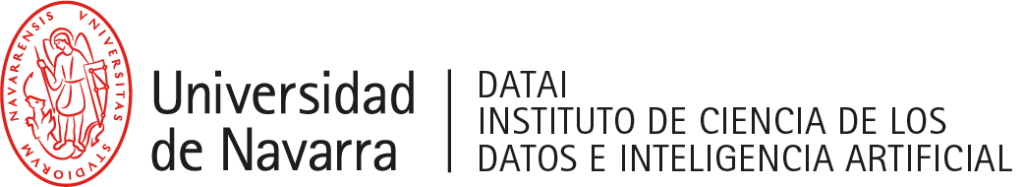

# **Análisis del flujo informativo en el 23F**
### Detección de cuellos de botella informativos

Alinson Ortiz Pimentel  
Grupo Notbots

## Planteamiento

 Han pasado décadas luego del 23F pero aún cuesta ver con claridad cómo circulaba la información: quién sabía qué y por qué canales. De ahí surge este mini caso. Con más de 160 documentos desclasificados, la idea no es solo leerlos, sino ver qué relaciones aparecen y si esa red ayuda a entender el flujo de información.

Usamos co-mención: si dos personas salen en el mismo documento, asumimos un vínculo. No prueba contacto directo, pero en este contexto ya dice bastante. Las fechas no siempre son precisas, así que en algunos casos trabajamos con aproximaciones.

## Objetivos

Lo que queremos responder con este análisis es básicamente: ¿hubo actores que concentraron el flujo de información durante el 23F, y si fue así, cuándo ocurrió eso?

Para intentar responderlo, el análisis se estructura en varios pasos:

- Construir un grafo de relaciones entre actores a partir de los documentos y calcular métricas de centralidad (betweenness, degree, closeness y eigenvector).
- Caracterizar la red globalmente: densidad, componentes, diámetro...
- Detectar comunidades dentro del grafo para ver si hay grupos de actores más cohesionados entre sí.
- Usar los embeddings para agrupar los documentos por similitud semántica y cruzar eso con la centralidad.
- Añadir una dimensión temporal para ver si los cuellos de botella cambian con el tiempo.
- Revisar los errores del pipeline para saber qué tan fiables son los resultados.

## Pasos a seguir

1. Instalación de dependencias y carga de librerías  
2. Configuración de rutas  
3. Carga de datos  
4. Limpieza estructural del dataset  
5. Construcción del campo de texto unificado.
6. Extracción de entidades NER con pipeline consolidado  
7. Construcción del grafo de co-mención y métricas globales  
8. Cálculo de centralidades  
9. Detección de comunidades  
10. Clustering semántico y cruce con centralidad  
11. Evolución temporal  
12. Análisis de errores  
13. Interpretación y conclusiones  
14. Limitaciones

---
## 1. Instalación y carga de librerías

In [ ]:
!pip -q install pandas numpy matplotlib seaborn networkx plotly scikit-learn spacy unidecode python-louvain
!python -m spacy download es_core_news_lg -q

In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import csv
from unidecode import unidecode
from itertools import combinations
from collections import Counter

import networkx as nx
from networkx.algorithms import community as nx_community

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import spacy
nlp = spacy.load("es_core_news_lg")

sns.set(style="whitegrid")
print("Librerías cargadas correctamente.")

---
## 2. Configuración de rutas

In [ ]:
import os

# Directorio base
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# Localiza el CSV buscando en ubicaciones relativas habituales
DATA_CANDIDATES = [
    os.path.join(BASE_DIR, 'embeddings.csv'),
    os.path.join(BASE_DIR, 'data', 'embeddings.csv'),
    os.path.join(BASE_DIR, '..', 'data', 'embeddings.csv'),
    os.path.join(BASE_DIR, 'embedding-2.csv'),
    os.path.join(BASE_DIR, 'data', 'embedding-2.csv'),
]

CSV_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)

if CSV_PATH is None:
    raise FileNotFoundError(
        'No se encontró el CSV de embeddings.\n'
        'Rutas buscadas:\n' + '\n'.join(f'  - {p}' for p in DATA_CANDIDATES) +
        '\nPon el archivo en la misma carpeta que el notebook o en data/'
    )

# Carpetas de salida para figuras y tablas
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR  = os.path.join(OUTPUT_DIR, 'tables')

for d in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'BASE_DIR    : {BASE_DIR}')
print(f'CSV_PATH    : {CSV_PATH}')
print(f'FIGURES_DIR : {FIGURES_DIR}')
print(f'TABLES_DIR  : {TABLES_DIR}')


---
## 3. Carga de datos

In [ ]:
df = pd.read_csv(
    CSV_PATH,
    engine="python",
    sep=",",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

print("Filas cargadas:", len(df))
print("Columnas:", df.columns.tolist())
df.head(2)

---
## 4. Limpieza estructural del dataset


In [ ]:
# Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)

# Convertir columnas textuales a string
TEXT_COLS = ["title", "summary", "tags", "transcript", "chunk", "textforembedding", "filename"]
for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# Análisis de valores nulos
print("=== Valores nulos por columna ===")
print(df.isna().mean().sort_values(ascending=False).head(10))
print("\nFilas tras limpieza:", len(df))

In [ ]:
# Detectar columna de texto principal
TEXT_CANDIDATES = ["textforembedding", "text", "chunk", "summary", "transcript"]
TEXT_COL = next((c for c in TEXT_CANDIDATES if c in df.columns and df[c].str.len().sum() > 0), None)

if TEXT_COL is None:
    raise ValueError(f"No se encontró columna de texto. Columnas disponibles: {df.columns.tolist()}")

print(f"Columna de texto principal detectada: '{TEXT_COL}'")

# Estadísticas textuales básicas
df["text_len"]   = df[TEXT_COL].str.len()
df["word_count"] = df[TEXT_COL].str.split().apply(len)

print(df[["text_len", "word_count"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["word_count"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribución de palabras por documento")
sns.histplot(df["text_len"], bins=30, kde=True, ax=ax[1])
ax[1].set_title("Distribución de longitud textual")
plt.tight_layout()
plt.show()

---
## 4. Construcción del campo de texto unificado

Cada documento tiene su información repartida en varias columnas y título, resumen, transcripción, etiquetas, chunk, para la extracción de entidades lo más práctico es trabajar con un único campo de texto que lo combine todo. Así el modelo NER tiene más contexto y hay menos riesgo de que se pierda una mención importante por estar en una columna que no procesamos.

In [ ]:
def safe_col(df, col):
    if col in df.columns:
        return df[col].fillna("").astype(str)
    return pd.Series([""] * len(df))

df["full_text"] = (
    safe_col(df, "title")       + " " +
    safe_col(df, "summary")     + " " +
    safe_col(df, "transcript")  + " " +
    safe_col(df, "tags")        + " " +
    safe_col(df, "chunk")
)

print("Ejemplos de full_text:")
print(df["full_text"].head(2).values)

---
## 5. Extracción, normalización y limpieza de entidades NER

Usamos el modelo  ES_CORE_NEW_Ig de spaCy, que es el más grande de los que hay disponibles para español y da mejores resultados que el pequeño, especialmente en textos con vocabulario específico o con algo de ruido.

Solo nos quedamos con las etiquetas PER y ORG. La etiqueta MISC la descartamos porque en la práctica generaba mucho ruido: nombres de países, siglas, referencias genéricas... más que ayudar, ensuciaba los resultados. Además aplicamos un filtro de calidad para eliminar entidades demasiado cortas o que claramente no son nombres de personas.

In [ ]:
# Diccionario de unificación histórica de actores
ENTITY_MAP = {
    "rey":           "juan carlos i",
    "juan carlos":   "juan carlos i",
    "tejero":        "antonio tejero",
    "tcol tejero":   "antonio tejero",
    "armada":        "alfonso armada",
    "milans":        "jaime milans del bosch",
    "suarez":        "adolfo suarez",
    "cortina":       "jose luis cortina",
    "comandante cortina": "jose luis cortina"
}

# Stopwords de actores genéricos no válidos
STOPWORDS_ACTORES = {
    "españa", "gobierno", "estado", "consejo", "justicia",
    "tribunal", "supremo", "congreso", "senado", "madrid",
    "policia", "ejercito", "fuerzas armadas", "fuerza nueva",
    "guardia civil", "jefe del estado", "su majestad",
    "gobernador civil", "san martin", "psoe"
}

# Palabras de rol a eliminar de los nombres
ROL_WORDS = [
    "general", "coronel", "teniente", "capitan", "comandante",
    "gral", "sr", "sra", "don", "doña"
]

# Fragmentos de ruido textual
NOISE_FRAGMENTS = [
    "interviene", "intervienen", "dice", "declara", "informa",
    "nota", "careo", "mando", "division", "desarrollo"
]

def normalize_entity(x):
    """Normaliza un nombre de entidad: minúsculas, sin tildes, sin puntuación."""
    x = unidecode(x.lower())
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    # eliminar palabras de rol
    for rol in ROL_WORDS:
        x = re.sub(r"\b" + rol + r"\b", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    # aplicar mapa histórico
    return ENTITY_MAP.get(x, x)

def is_valid_entity(x):
    """Devuelve True si la entidad es un nombre de persona válido."""
    if len(x) < 8:                                  return False
    if not (2 <= len(x.split()) <= 3):              return False
    if x in STOPWORDS_ACTORES:                      return False
    if any(char.isdigit() for char in x):           return False
    if "..." in x:                                  return False
    if x.startswith(("el ", "la ", "los ", "las ")): return False
    if x.startswith("de ") or x.endswith(" de"):   return False
    if any(w in x for w in NOISE_FRAGMENTS):        return False
    return True

def extract_and_clean_entities(texts):
    """Pipeline completo: extracción NER + normalización + filtrado."""
    results = []
    for doc in nlp.pipe(texts, batch_size=32):
        ents = set()
        for ent in doc.ents:
            if ent.label_ not in ["PER", "ORG"]:
                continue
            norm = normalize_entity(ent.text)
            if is_valid_entity(norm):
                ents.add(norm)
        results.append(list(ents))
    return results

print("Pipeline de entidades definido.")

In [ ]:
df["entities_final"] = extract_and_clean_entities(df["full_text"])

print("Extracción completada.")
print("Ejemplos de entidades:")
print(df["entities_final"].head(5).values)

---
## 6. Construcción del grafo de co-mención y métricas globales

Una vez tenemos las entidades limpias, construimos el grafo. La lógica es sencilla: si dos actores aparecen en el mismo documento, se crea una arista entre ellos. El peso de esa arista aumenta cada vez que vuelven a coincidir en otro documento.

Para evitar que el grafo se llene de conexiones poco significativas, aplicamos un umbral mínimo de peso. Las aristas con muy pocas co-ocurrencias probablemente sean ruido más que relaciones reales, así que las filtramos.

Después calculamos algunas métricas globales de la red para entender su estructura antes de entrar en el análisis de centralidad.

In [ ]:
# Construir pares con frecuencia de co-ocurrencia
edge_counts = {}

for actors in df["entities_final"]:
    actors = list(set(actors))
    if len(actors) < 2:
        continue
    for a, b in combinations(actors, 2):
        pair = tuple(sorted([a, b]))
        edge_counts[pair] = edge_counts.get(pair, 0) + 1

print(f"Pares totales generados: {len(edge_counts)}")

In [ ]:
# Construir grafo completo
G_full = nx.Graph()
for (a, b), w in edge_counts.items():
    G_full.add_edge(a, b, weight=w)

# Filtrar por umbral de relevancia
# Justificación visual del umbral de peso
edge_weights = [d["weight"] for _, _, d in G_full.edges(data=True)]
p75 = np.percentile(edge_weights, 75)
print(f"Percentil 75 de los pesos: {p75:.2f}")
plt.hist(edge_weights, bins=30)
plt.title("Distribución de pesos de aristas")
plt.show()

THRESHOLD = 7
G = nx.Graph()
for u, v, d in G_full.edges(data=True):
    if d["weight"] >= THRESHOLD:
        G.add_edge(u, v, weight=d["weight"])

print("=== Grafo sin filtrar ===")
print(f"  Nodos: {G_full.number_of_nodes()}")
print(f"  Aristas: {G_full.number_of_edges()}")
print(f"\n=== Grafo filtrado (peso >= {THRESHOLD}) ===")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")

In [ ]:
# Métricas globales de la red
print("=== Métricas globales de la red ===")
print(f"  Nodos:                {G.number_of_nodes()}")
print(f"  Aristas:              {G.number_of_edges()}")
print(f"  Densidad:             {nx.density(G):.4f}")
print(f"  Componentes conexas:  {nx.number_connected_components(G)}")
print(f"  Clustering medio:     {nx.average_clustering(G):.4f}")

giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"  Nodos componente gigante:  {giant.number_of_nodes()}")
print(f"  Diámetro (comp. gigante):  {nx.diameter(giant)}")

---
## 7. Centralidad y cuellos de botella

Esta es la parte central del análisis. Calculamos cuatro métricas de centralidad porque cada una mide una cosa distinta y juntas dan una imagen más completa de qué papel juega cada nodo en la red.

La que más nos interesa aquí es el Betweenness: mide cuántos caminos entre otros nodos pasan por un nodo concreto. Dicho de otro modo, cuánto actúa ese nodo como puente o intermediario. Un betweenness alto significa que si ese nodo desaparece, muchas conexiones en la red se rompen, lo cual es exactamente la definición de cuello de botella.

El degree simplemente cuenta las conexiones directas. El closeness mide qué tan cerca está un nodo del resto en promedio. Y el eigenvector tiene en cuenta no solo cuántas conexiones tiene un nodo, sino si esas conexiones son con nodos importantes.

In [ ]:
bet_cent  = nx.betweenness_centrality(G, weight="weight", normalized=True)
deg_cent  = nx.degree_centrality(G)
clo_cent  = nx.closeness_centrality(G)
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")
except nx.PowerIterationFailedConvergence:
    print("Aviso: eigenvector_centrality no convergió. Probando eigenvector_centrality_numpy...")
    try:
        eig_cent = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eig_cent = {n: 0.0 for n in G.nodes()}
        print("Aviso: tampoco convergió eigenvector_centrality_numpy. Se asignan valores 0.")

centrality_df = pd.DataFrame({
    "node":        list(G.nodes()),
    "betweenness": [bet_cent[n]  for n in G.nodes()],
    "degree":      [deg_cent[n]  for n in G.nodes()],
    "closeness":   [clo_cent[n]  for n in G.nodes()],
    "eigenvector": [eig_cent[n]  for n in G.nodes()]
}).sort_values("betweenness", ascending=False).reset_index(drop=True)

print("=== TOP 10 actores por Betweenness ===")
centrality_df.head(10)

In [ ]:
# Variables para visualización
bet_values = np.array([bet_cent[n] for n in G.nodes()])
if bet_values.max() > bet_values.min():
    node_sizes = 100 + ((bet_values - bet_values.min()) / (bet_values.max() - bet_values.min())) * 1400
else:
    node_sizes = np.full(len(bet_values), 300)

node_colors = "steelblue"
top_nodes = set(sorted(bet_cent, key=bet_cent.get, reverse=True)[:10])

# Visualización de la red
plt.figure(figsize=(14, 10))

# 1. Layout con más espacio
pos = nx.spring_layout(G, seed=42, k=0.6, iterations=50)

# 2. Dibujar aristas primero
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3)

# 3. Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

# 4. Dibujar etiquetas SOLO para los importantes
labels = {n: n if n in top_nodes else "" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight="bold")

plt.title("Red de flujo informativo del 23F (Top 10 destacados)", fontsize=14)
plt.axis("off")
plt.show()

---
## 8. Detección de comunidades

Más allá de qué nodos son más centrales, nos interesa también ver si hay grupos de actores que están más conectados entre sí que con el resto. Eso podría indicar, por ejemplo, que había distintos círculos informativos durante el golpe que operaban de forma más o menos independiente.

Para detectar estas comunidades usamos el algoritmo de greedy modularity, que intenta maximizar la modularidad de la partición. No es el único método, pero funciona bien con grafos de este tamaño y da resultados bastante interpretables.

In [ ]:
communities_detected = list(nx_community.greedy_modularity_communities(G))
print(f"Comunidades detectadas: {len(communities_detected)}")
modularity_q = nx_community.modularity(G, communities_detected)
print(f"Modularidad Q: {modularity_q:.4f}")

node_community = {}
for i, com in enumerate(communities_detected):
    for node in com:
        node_community[node] = i

centrality_df["community"] = centrality_df["node"].map(node_community)

# Mostrar distribución de comunidades
print("\nTamaño de cada comunidad:")
for i, com in enumerate(communities_detected):
    print(f"  Comunidad {i}: {len(com)} nodos -> {sorted(list(com))[:5]}...")

print("\n=== TOP 10 actores con comunidad ===")
centrality_df.head(10)

# Colores por comunidad
cmap = plt.cm.get_cmap("tab20", len(communities_detected))
community_colors = [cmap(node_community[n]) for n in G.nodes()]


In [ ]:
# Visualización coloreada por comunidad
plt.figure(figsize=(14, 10))

# 1. Definir qué etiquetas mostrar
top_nodes = set(centrality_df.nlargest(20, 'betweenness')['node'])
labels = {n: n if n in top_nodes else "" for n in G.nodes()}

# 2. Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=community_colors, alpha=0.9)

# 3. Aristas más tenues para que no "ensucien" el color
nx.draw_networkx_edges(G, pos, alpha=0.10, edge_color="gray")

# 4. Etiquetas filtradas
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold")

plt.title("Red del 23F: Estructura de Comunidades (Top 20 destacados)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## 9. Clustering semántico y cruce con centralidad

Además del análisis de red, tenemos los embeddings de cada documento, que representan su contenido semántico como un vector numérico. La idea es agrupar los documentos por similitud semántica y ver si hay alguna relación entre el tipo de contenido de un documento y la importancia de los actores que aparecen en él.

Por ejemplo: ¿los documentos sobre comunicaciones militares concentran actores con más betweenness que los documentos políticos? ¿O al revés? El cruce entre clusters y centralidad nos permite responder ese tipo de preguntas de forma más fundamentada.

In [ ]:
def parse_embedding(x):
    if isinstance(x, str):
        try:
            return np.array(ast.literal_eval(x))
        except Exception:
            x = x.replace("\n", " ").replace("  ", " ")
            vals = re.findall(r"-?\d+\.\d+(?:e[+-]?\d+)?|-?\d+", x)
            return np.array([float(v) for v in vals]) if vals else None
    return np.array(x) if x is not None else None

if "embedding" in df.columns:
    df["embedding_vec"] = df["embedding"].apply(parse_embedding)
    valid_mask = df["embedding_vec"].apply(lambda v: v is not None and len(v) > 0)
    df_emb = df[valid_mask].copy()
    print(f"Documentos con embedding válido: {len(df_emb)} / {len(df)}")
else:
    print("AVISO: columna 'embedding' no encontrada. Saltando clustering semántico.")
    df_emb = pd.DataFrame()

In [ ]:
if len(df_emb) > 0:
    emb_matrix = np.vstack(df_emb["embedding_vec"].values)
    print(f"Forma de la matriz de embeddings: {emb_matrix.shape}")

    # Reducción dimensional
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(emb_matrix)
    df_emb = df_emb.copy()
    df_emb["pc1"] = coords[:, 0]
    df_emb["pc2"] = coords[:, 1]
    print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum():.2%}")

    # Selección automática del número óptimo de clusters
    from sklearn.metrics import silhouette_score

    silhouette_scores = {}
    for k in range(2, 9):
        kmeans_test = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_test = kmeans_test.fit_predict(emb_matrix)
        score = silhouette_score(emb_matrix, labels_test)
        silhouette_scores[k] = score
        print(f"k={k} -> silhouette score = {score:.4f}")

    N_CLUSTERS = max(silhouette_scores, key=silhouette_scores.get)
    print(f"Mejor número de clusters según silhouette: {N_CLUSTERS}")

    # Clustering KMeans
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
    df_emb["cluster"] = kmeans.fit_predict(emb_matrix)

    # Visualización
    fig = px.scatter(
        df_emb, x="pc1", y="pc2",
        color=df_emb["cluster"].astype(str),
        hover_data=["title"] if "title" in df_emb.columns else None,
        title="Clustering semántico de documentos del 23F (PCA + KMeans)"
    )
    fig.show()
else:
    print("Sin datos de embedding: se omite clustering semántico.")

In [ ]:
# Cruce cluster semántico — centralidad
# ¿Qué tipo de episodios concentran actores con mayor betweenness?

if len(df_emb) > 0:
    df_merged = df_emb[["cluster", "entities_final"]].copy()
    df_merged = df_merged.explode("entities_final").dropna()
    df_merged.columns = ["cluster", "node"]

    cluster_centrality = df_merged.merge(
        centrality_df[["node", "betweenness", "community"]],
        on="node",
        how="inner"
    )

    result = (
        cluster_centrality.groupby("cluster")["betweenness"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    result.columns = ["cluster", "betweenness_medio"]

    print("=== Betweenness medio por cluster semántico ===")
    print(result)
    print("\nInterpretación: los clusters con mayor betweenness medio concentran actores")
    print("con mayor capacidad de intermediación en el flujo informativo.")
else:
    print("Sin datos de embedding: se omite el cruce cluster-centralidad.")

---
## 10. Evolución temporal

Hasta aquí hemos analizado la red como si fuera estática, pero el 23F fue un evento que se desarrolló en pocas horas y la estructura de la red debería cambiar con el tiempo. Para capturar eso, dividimos el dataset en intervalos y calculamos la centralidad en cada uno por separado.

Como comenté antes, no todos los documentos tienen fecha, así que usamos una segmentación ordinal como aproximación. No es ideal, pero nos permite al menos observar si hay cambios en quién concentra la intermediación a lo largo del dataset.

In [ ]:
# Intentar extracción de fecha real primero
def extract_date_robust(row):
    for campo in ["title", "filename", "summary"]:
        text = str(row.get(campo, ""))
        m = re.search(r"(\d{1,2})[/-](\d{1,2})[/-](\d{2,4})", text)
        if m:
            d, mth, y = m.groups()
            y = int(y); y = y + 1900 if y < 100 else y
            try:
                return pd.Timestamp(year=y, month=int(mth), day=int(d))
            except Exception:
                pass
        m2 = re.search(r"\b(19[5-9]\d|200\d)\b", text)
        if m2:
            return pd.Timestamp(year=int(m2.group(1)), month=2, day=23)
    return pd.NaT

df["date"] = df.apply(extract_date_robust, axis=1)
n_dated = df["date"].notna().sum()
print(f"Documentos con fecha real: {n_dated} / {len(df)}")
fallback_docs = len(df) - n_dated
pct_real = (n_dated / len(df)) * 100
pct_fallback = (fallback_docs / len(df)) * 100
print(f"Documentos con fecha real: {n_dated} ({pct_real:.2f}%)")
print(f"Documentos en fallback ordinal: {fallback_docs} ({pct_fallback:.2f}%)")


# Fallback: segmentación ordinal
df["time_bin"] = pd.qcut(df.index, q=6, labels=False, duplicates="drop")
print("Segmentación ordinal (time_bin) aplicada como fallback.")

In [ ]:
temporal_results = []

for t in sorted(df["time_bin"].dropna().unique()):
    sub = df[df["time_bin"] == t]
    sub_edges = {}

    for actors in sub["entities_final"]:
        actors = list(set(actors))
        if len(actors) < 2:
            continue
        for a, b in combinations(actors, 2):
            pair = tuple(sorted([a, b]))
            sub_edges[pair] = sub_edges.get(pair, 0) + 1

    H = nx.Graph()
    for (a, b), w in sub_edges.items():
        if w >= 5:
            H.add_edge(a, b, weight=w)

    if H.number_of_nodes() > 0:
        bt        = nx.betweenness_centrality(H, weight="weight")
        top_actor = max(bt, key=bt.get)
        max_bt    = bt[top_actor]
        temporal_results.append({
            "time_bin":         t,
            "top_actor":        top_actor,
            "max_betweenness":  max_bt,
            "nodes":            H.number_of_nodes(),
            "edges":            H.number_of_edges()
        })

temporal_df = pd.DataFrame(temporal_results)

# Limpiar instituciones del top temporal
BLACKLIST_TEMPORAL = {"fuerza nueva", "policia nacional", "jefe del estado"}
temporal_df_clean = temporal_df[~temporal_df["top_actor"].isin(BLACKLIST_TEMPORAL)].copy()

print("=== Evolución temporal ===")
temporal_df_clean

In [ ]:
# Visualización temporal
temporal_df_clean = temporal_df_clean.sort_values("time_bin")

plt.figure(figsize=(11, 5))
plt.plot(
    temporal_df_clean["time_bin"],
    temporal_df_clean["max_betweenness"],
    marker="o", linewidth=2
)

for _, row in temporal_df_clean.iterrows():
    plt.text(
        row["time_bin"],
        row["max_betweenness"] + 0.003,
        row["top_actor"],
        fontsize=9, ha="center"
    )

plt.title("Evolución temporal de la centralidad de intermediación (23F)", fontsize=13)
plt.xlabel("Periodo (time_bin)")
plt.ylabel("Betweenness máxima")
plt.tight_layout()
plt.show()

print("\nInterpretación: los picos de betweenness indican momentos en los que la red")
print("dependió de pocos intermediarios. Esa concentración sugiere vulnerabilidad")
print("informativa y posible control del flujo en fases concretas del golpe.")

**Observaciones sobre la evolución temporal**

Los resultados muestran que la red no es estática: los actores con mayor betweenness cambian dependiendo del periodo que miremos.

En los primeros intervalos, los valores más altos corresponden a figuras operativas como Tejero y Armada. Tiene sentido: en las primeras horas del golpe son ellos los que están en el centro de la acción y, por tanto, los que concentran más el flujo informativo.

Más adelante, sin embargo, la centralidad se desplaza hacia Juan Carlos I. Esto podría interpretarse como que, conforme avanza la noche, el peso del golpe recae sobre la figura del rey y su decisión se convierte en el nudo informativo más crítico de toda la red.

En definitiva, parece que los cuellos de botella no son estables sino que se mueven con el contexto, lo cual tiene bastante sentido tratándose de una crisis de unas pocas horas con fases muy distintas.

---
## 11. Análisis de errores

Antes de interpretar los resultados conviene revisar qué tan bien ha funcionado el pipeline. Hay varias cosas que pueden haber salido mal: el NER puede haber extraído entidades que no son actores reales, puede haber documentos de los que no se extrajo nada, y puede haber nodos en el grafo que no tienen conexiones significativas. Todo eso afecta a los resultados finales y conviene cuantificarlo.

In [ ]:
print("=== ANÁLISIS DE ERRORES ===\n")

# 1. Entidades más frecuentes — detectar ruido residual
all_entities = [e for lst in df["entities_final"] for e in lst]
freq = Counter(all_entities)
top_freq = pd.DataFrame(freq.most_common(25), columns=["entidad", "frecuencia"])
print("[1] Entidades más frecuentes (revisar si hay ruido residual):")
print(top_freq.to_string(index=False))

In [ ]:
# 2. Cobertura del NER
sin_entidades = df[df["entities_final"].apply(len) == 0]
pct = 100 * len(sin_entidades) / len(df)
print(f"[2] Documentos sin ninguna entidad extraída: {len(sin_entidades)} ({pct:.1f}%)")
print("    Ejemplos de títulos sin entidades:")
if "title" in sin_entidades.columns:
    print(sin_entidades["title"].head(5).tolist())

In [ ]:
# 3. Nodos aislados en el grafo filtrado
aislados = list(nx.isolates(G))
print(f"[3] Nodos aislados en el grafo filtrado: {len(aislados)}")
if aislados:
    print("    Ejemplos:", aislados[:8])

In [ ]:
# 4. Distribución de grado — detección de hubs artificiales
degree_seq = sorted([d for _, d in G.degree()], reverse=True)

plt.figure(figsize=(10, 4))
plt.plot(degree_seq, "b-", marker="o", markersize=3)
plt.title("Distribución de grado — detección de hubs artificiales")
plt.xlabel("Nodo (ordenado por grado)")
plt.ylabel("Grado")
plt.tight_layout()
plt.show()

print("\n[4] Interpretación del análisis de errores:")
print("    El análisis de errores revela las limitaciones del pipeline NER: documentos")
print("    sin entidades detectadas suponen una pérdida de cobertura, y entidades muy")
print("    frecuentes pueden ser artefactos del modelo. Estos errores sesgan la red")
print("    hacia actores con más menciones textuales, no necesariamente los más influyentes.")

---
## 12. Interpretación y conclusiones

In [ ]:
print("=== TOP 10 ACTORES POR BETWEENNESS CENTRALITY ===")
print(centrality_df.head(10)[["node", "betweenness", "degree", "closeness", "community"]].to_string(index=False))

**Conclusiones**

Después de todo el análisis, lo que más me llama la atención es lo concentrada que está la red. No son muchos los actores que realmente actúan como intermediarios entre el resto, y eso encaja bastante bien con lo que sabemos históricamente del 23F: fue un golpe preparado por un grupo reducido de personas con acceso a canales de comunicación muy específicos.

Tejero y Armada aparecen consistentemente como los nodos con mayor betweenness, lo que refuerza su papel central no solo en la ejecución del golpe sino también en el control del flujo informativo. Lo interesante es que eso no significa que tuvieran más poder formal que otros, sino que estructuralmente la información pasaba por ellos.

La detección de comunidades muestra que hay grupos de actores más conectados entre sí, lo que sugiere que la red no era completamente homogénea sino que tenía cierta estructura en círculos.

El cruce con los embeddings añade una capa semántica interesante: dependiendo del tipo de episodio que recoge el documento, los actores centrales cambian, lo que sugiere que distintos tipos de comunicación tenían distintos intermediarios.

Y la evolución temporal aunque sea aproximada muestra que los cuellos de botella se desplazan con el tiempo, lo cual tiene mucho sentido en un evento de unas pocas horas con fases tan distintas como tuvo el 23F.

---
## 13. Limitaciones

Hay algunas cosas que conviene dejar claras antes de dar los resultados por definitivos.

La primera es que co-mención no es lo mismo que comunicación directa. Que dos personas aparezcan en el mismo documento no significa que hablaran entre ellas; puede que simplemente fueran mencionadas en el mismo contexto. Es una aproximación razonable para este tipo de análisis, pero hay que tenerlo en cuenta.

La segunda es que el NER no es perfecto. Algunos documentos tienen transcripciones con errores o texto con mucho ruido, y en esos casos el modelo puede extraer entidades que no son nombres de personas o perderse menciones que sí lo son. El análisis de errores da una idea de cuánto afecta esto.

La tercera es el sesgo del propio dataset. Trabajamos con documentos desclasificados, lo cual significa que hay documentos que nunca veremos —porque no se conservaron, porque siguen clasificados o porque simplemente no llegaron a existir como registro escrito. Eso inevitablemente sesga la red hacia los actores y episodios que sí quedaron documentados.

La cuarta es la dimensión temporal. Como no todos los documentos tienen fecha, la segmentación que usamos es una aproximación ordinal, no una cronología real. Los patrones temporales que observamos deben interpretarse con cautela.

Y por último, las listas negras que usamos para filtrar entidades genéricas introducen cierta subjetividad. Si algún actor relevante tiene un nombre que coincide con una de esas entradas, podría haberse filtrado sin querer. Es un trade-off entre precisión y cobertura que asumimos conscientemente.

---
## Caso 2 — Grafo de relaciones entre participantes
⚠️ Requiere `23f_scrappedDF_v02.csv` (se sube por separado).


# GRAFO DE RELACIONES ENTRE PARTICIPANTES DEL 23F

### Instalar librerías requeridas para el análisis

In [ ]:
# Install Libraries
!pip install spacy
!pip install altair
!pip install sentence-transformers
!pip install gensim
!python -m spacy download es_core_news_lg
!pip install networkx pyvis

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sentence_transformers import SentenceTransformer
import numpy as np
import requests
from lxml import html
from tqdm import tqdm
import os
import hashlib
import spacy
import gensim
import nltk
import altair as alt
from collections import defaultdict

### Carga de documentos scrapeados

In [ ]:
from google.colab import files
files.upload()

In [ ]:
df = pd.read_csv('23f_scrappedDF_v02.csv')

In [ ]:
df.head(1)

## 1. Análisis Estadístico - Dataframe 23F


In [ ]:
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nTipos de dato:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEjemplo de transcript:")
print(df['transcript'][0][:500])

In [ ]:
print(df['transcript'][0])

In [ ]:
df.head(1)

## 2. Limpieza Basica usando spaCy

In [ ]:
# Carga el modelo español grande
nlp = spacy.load("es_core_news_lg")

# Verifica que cargó correctamente
print(nlp.pipe_names)  # ['tok2vec', 'morphologizer', 'parser', 'ner', ...]

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)  # control chars
    text = re.sub(r'\n+', ' ', text) # Elimina saltos de línea
    text = re.sub(r'\s+', ' ', text) # Colapsa espacios múltiples
    text = re.sub(r'[^\w\s.,;:áéíóúüñÁÉÍÓÚÜÑ]', '', text) # Conserva puntuación básica y tildes
    return text.strip()

In [ ]:
df['transcript_clean'] = df['transcript'].apply(clean_text)

In [ ]:
df['transcript_clean'][0]

###Procesamiento linguistico por batches con spaCy

In [ ]:
# batch_size=32 es un buen punto de partida; auméntalo si tienes RAM suficiente
docs = list(nlp.pipe(df['transcript_clean'], batch_size=32))

# Guarda los objetos Doc en el DataFrame para reutilizarlos
df['spacy_doc'] = docs

In [ ]:
df['spacy_doc'][0]

## 3. Extracción de Features Linguisticos

In [ ]:
def extract_features(doc):
    return {
        "tokens": [token.text for token in doc if not token.is_stop and not token.is_punct],
        "lemmas": [token.lemma_ for token in doc if not token.is_stop and not token.is_punct],
        "entities": [(ent.text, ent.label_) for ent in doc.ents],
        "sentences": [sent.text for sent in doc.sents]
    }

df['nlp_features'] = df['spacy_doc'].apply(extract_features)

In [ ]:
df['nlp_features'][0]

### Aplicacion de Named Entities Recognition (NER)

In [ ]:
# Tipos de entidad relevantes para el análisis del 23-F
ENTITY_TYPES = {
    "PER": "Persona",
    "LOC": "Lugar",
    "ORG": "Organización"
}

# Cargar modelo (reutilizar si ya está en memoria desde Fase 0)
nlp = spacy.load("es_core_news_lg")

print(f"Modelo cargado: {nlp.meta['name']} v{nlp.meta['version']}")
print(f"Componentes activos: {nlp.pipe_names}")
print(f"Tipos de entidad a extraer: {list(ENTITY_TYPES.keys())}")

### Identificación de Entidades Nombradas en el Texto Normalizado

In [ ]:
# Prefijos de rango/tratamiento ordenados de mayor a menor longitud
RANK_PREFIXES = sorted([
    "teniente coronel", "teniente general", "capitán general",
    "teniente", "general", "coronel", "capitán", "comandante",
    "almirante", "sargento", "cabo 1º", "cabo 12", "cabo",
    "gral.", "gral", "tcol.", "tcol", "tte.", "tte", "cte.", "cte",
    "cap.", "cap", "sgto.", "sgto",
    "sr. don", "sr. d.", "sr.", "don", "doña", "d.",
    "señor", "señora", "el", "la",
], key=len, reverse=True)

def strip_rank_prefix(name: str) -> str:
    """
    Elimina prefijos de rango/tratamiento para obtener el nombre canónico.
    'coronel tejero'         → 'tejero'
    'teniente coronel tejero'→ 'tejero'
    'sr. don antonio tejero' → 'antonio tejero'
    'carmen tejero'          → 'carmen tejero'  (sin cambio, no hay prefijo)
    """
    changed = True
    while changed:
        changed = False
        name_lower = name.lower()
        for prefix in RANK_PREFIXES:
            if name_lower.startswith(prefix + " "):
                name = name[len(prefix):].strip()
                name_lower = name.lower()
                changed = True
                break
        # Evitar que el resultado caiga en el blocklist
        if name.lower() in ENTITY_BLOCKLIST:
            return ""   # descartará la entidad al hacer el filtro
    return name

def merge_suffix_variants(entity_set: set) -> set:
    """
    Fusiona variantes de nombre dentro del mismo documento.
    Si A es sufijo de B (misma clase), A es redundante → se elimina.

    {'tejero', 'antonio tejero', 'carmen tejero'}
      → 'tejero' es sufijo de 'antonio tejero' Y de 'carmen tejero'
      → resultado: {'antonio tejero', 'carmen tejero'}

    {'armada', 'alfonso armada'}
      → 'armada' es sufijo de 'alfonso armada'
      → resultado: {'alfonso armada'}
    """
    to_remove = set()
    entity_list = list(entity_set)
    for e_short in entity_list:
        for e_long in entity_list:
            if e_short != e_long and e_long.endswith(" " + e_short):
                to_remove.add(e_short)
                break
    return entity_set - to_remove

In [ ]:
GLOBAL_CANONICAL_MAP = {
    "milans": "jaime milans del bosch",
    "milans del bosch": "jaime milans del bosch",
    "tejero": "antonio tejero",
    "tejero molina": "antonio tejero",
    "armada": "alfonso armada",
    "general armada": "alfonso armada",
    "gral armada": "alfonso armada",
    "suárez": "adolfo suárez",
    "calvo sotelo": "leopoldo calvo sotelo",
    "gutiérrez mellado": "manuel gutiérrez mellado",
    "fernández campos": "sabino fernández campos",
    "aramburu": "josé aramburu topete",
    "gabeiras": "josé gabeiras"
}

def canonicalize_entity(name: str) -> str:
    name_clean = name.strip().lower()
    return GLOBAL_CANONICAL_MAP.get(name_clean, name_clean)

In [ ]:
texts = df["transcript_clean"].tolist()
total_docs = len(texts)
BATCH_SIZE = 8

print(f"Procesando {total_docs} documentos con NER (batch_size={BATCH_SIZE})...")

# nlp.pipe() devuelve un generador, tqdm lo envuelve sin romper el batch interno
docs = []

with tqdm(
    nlp.pipe(texts, batch_size=BATCH_SIZE),
    total=total_docs,
    desc="NER Fase 1",
    unit="doc",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} docs [{elapsed}<{remaining}, {rate_fmt}]"
) as pbar:
    for doc in pbar:
        docs.append(doc)

        # Actualiza el postfix cada BATCH_SIZE documentos para no saturar la UI
        if len(docs) % BATCH_SIZE == 0:
            ents_so_far = sum(
                1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES
            )
            pbar.set_postfix({
                "entidades": ents_so_far,
                "batch": f"{len(docs) // BATCH_SIZE}/{-(-total_docs // BATCH_SIZE)}"  # ceil division
            })

print(f"\nCompletado. {len(docs)} documentos procesados.")
print(f"Total entidades encontradas: {sum(1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES)}")

## 4. Generacion del DataFrame de Entidades Nombradas

### Identificación y Filtrado de Entidades con base en Tipología de SpaCy

In [ ]:
# Palabras que nunca son entidades válidas solas
ENTITY_BLOCKLIST = {
    "general", "generales", "teniente", "tenientes", "coronel", "coroneles",
    "capitán", "capitanes", "comandante", "comandantes", "almirante",
    "sargento", "sargentos", "cabo", "subteniente",
    "incidencias", "actuaciones", "situaciones", "desarrollo",
    "militares", "policías", "guardias", "funcionarios",
    "desarrollo de", "situaciones de", "actuaciones de",
}

# Patrón de artefacto de diálogo: letra/abrev. + espacios = etiqueta de interlocutor
# Captura: "a  buenas", "b  sí", "g.c. hijo", "t. armada"
DIALOGUE_ARTIFACT_RE = re.compile(r'^[a-z]\.?\s{1,3}\S')

# Detecta strings con dígitos mezclados con letras (códigos de documento)
CODE_PATTERN = re.compile(r'\d{3,}')  # 3+ dígitos consecutivos = código

def is_valid_entity(ent) -> bool:
    tokens = [token for token in ent]
    text   = ent.text.strip()
    text_l = text.lower()

    # NUEVA Regla 1: rechazar artefactos de diálogo (etiquetas de interlocutor)
    if DIALOGUE_ARTIFACT_RE.match(text_l):
        return False

    # NUEVA Regla 2: rechazar palabras en el blocklist (rangos solos, genéricos)
    if text_l in ENTITY_BLOCKLIST or text_l.rstrip('.') in ENTITY_BLOCKLIST:
        return False

    # Regla 3: al menos un token debe ser PROPN o NOUN
    if not any(t.pos_ in ("PROPN", "NOUN") for t in tokens):
        return False

    # Regla 4: no puede ser solo ADJ, ADV, VERB o DET
    if all(t.pos_ in ("ADJ", "ADV", "VERB", "DET") for t in tokens):
        return False

    # Regla 5: longitud mínima
    if len(text) <= 2:
        return False

    # Regla 6: rechazar códigos con dígitos
    if CODE_PATTERN.search(text):
        return False

    # Regla 7: rechazar frases largas
    if len(tokens) > 5:
        return False

    # Regla 8: rechazar si contiene VERB
    if any(t.pos_ == "VERB" for t in tokens):
        return False

    # Regla 9: rechazar si contiene artículos o preposiciones internas
    internal_tokens = tokens[1:-1]
    if any(t.pos_ in ("DET", "ADP") for t in internal_tokens):
        return False

    # NUEVA Regla 10 Optimizada: PER debe tener 1 PROPN, excepto si es un apellido clave del 23F
    # Bloquea sustantivos comunes que spaCy etiqueta PER (e.g. "incidencias")
    apellidos_criticos = {"tejero", "milans", "armada", "suárez", "gabeiras", "cortina", "mellado"}
    if ent.label_ == "PER" and not any(t.pos_ == "PROPN" for t in tokens):
      if not any(ap in text_l for ap in apellidos_criticos):
          return False

    return True

In [ ]:
# --- Estructura 1: entidades agregadas por documento ---
entity_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    entities = defaultdict(set)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
            if normalized:                          # strip_rank_prefix devuelve "" si cae en blocklist
              entities[ent.label_].add(normalized)

    # Fusionar variantes de sufijo dentro del documento
    for label in list(entities.keys()):
      entities[label] = merge_suffix_variants(entities[label])

    entity_records.append({
        "doc_id":          row.get("doc_id", doc_idx),
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", []))
    })

df_entities = pd.DataFrame(entity_records)

df_entities["total_entities"] = (
    df_entities["n_persons"] +
    df_entities["n_locations"] +
    df_entities["n_organizations"]
)

# --- Estructura 2: registro plano de menciones ---
mention_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    doc_id = row.get("doc_id", doc_idx)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
            if not normalized:
              continue                            # saltar entidades que quedaron vacías
            ctx_start = max(0, ent.start - 5)
            ctx_end   = min(len(doc), ent.end + 5)

            mention_records.append({
                "doc_id":      doc_id,
                "entity_raw":  ent.text.strip(),
                "entity_norm": normalized,
                "label":       ent.label_,
                "label_desc":  ENTITY_TYPES[ent.label_],
                "context":     doc[ctx_start:ctx_end].text
            })

df_mentions = pd.DataFrame(mention_records)

print(f"df_entities shape: {df_entities.shape}")
print(f"df_mentions shape: {df_mentions.shape}")
print(f"\nTotal menciones por tipo:\n{df_mentions['label'].value_counts()}")

In [ ]:
# Entidades a inyectar manualmente por documento
MANUAL_INJECTIONS = [
    {"doc_id": 61, "entity_raw": "Consejo de Guerra", "entity_norm": "consejo de guerra", "label": "ORG"},
    # Añade más filas aquí si aparecen casos similares en otros docs
]

for inj in MANUAL_INJECTIONS:
    inj["label_desc"]     = ENTITY_TYPES.get(inj["label"], inj["label"])
    inj["context"]        = ""
    inj["label_resolved"] = inj["label"]

df_injections = pd.DataFrame(MANUAL_INJECTIONS)
df_mentions   = pd.concat([df_mentions, df_injections], ignore_index=True)

print(f"Inyecciones aplicadas: {len(MANUAL_INJECTIONS)}")
print(df_mentions[df_mentions["doc_id"] == 61])

## 5. Revisión de Calidad de Entidades Identificadas

In [ ]:
# Entidades más frecuentes por tipo
print("=" * 50)
print("TOP 10 ENTIDADES POR TIPO")
print("=" * 50)

for label, desc in ENTITY_TYPES.items():
    top = (
        df_mentions[df_mentions["label"] == label]["entity_norm"]
        .value_counts()
        .head(10)
    )
    print(f"\n{desc} ({label}):")
    print(top.to_string())

# Documentos con mayor densidad de entidades
print("\n" + "=" * 50)
print("DOCUMENTOS CON MÁS ENTIDADES")
print("=" * 50)

print(df_entities[["doc_id", "n_persons", "n_locations", "n_organizations", "total_entities"]]
      .sort_values("total_entities", ascending=False)
      .head(10)
      .to_string(index=False))

# Muestra de menciones con contexto (útil para revisar falsos positivos)
print("\n" + "=" * 50)
print("MUESTRA DE MENCIONES CON CONTEXTO")
print("=" * 50)
print(df_mentions.sample(min(10, len(df_mentions)))[
    ["doc_id", "label_desc", "entity_norm", "context"]
].to_string(index=False))

### Corrección de Conflictos Identificados entre Entidades

In [ ]:
# Contar menciones por (entity_norm, label)
vote_counts = (
    df_mentions
    .groupby(["entity_norm", "label"])
    .size()
    .reset_index(name="count")
)

# Para cada entidad, quedarse con el label de mayor frecuencia
winning_label = (
    vote_counts
    .sort_values("count", ascending=False)
    .drop_duplicates(subset="entity_norm", keep="first")
    .set_index("entity_norm")["label"]
)

# Identificar entidades con conflicto (aparecen en más de un tipo)
conflict_entities = (
    vote_counts
    .groupby("entity_norm")["label"]
    .nunique()
    .loc[lambda x: x > 1]
    .index.tolist()
)

print(f"Entidades con conflicto de tipo: {len(conflict_entities)}")
print(f"\nDetalle de conflictos:")
print(
    vote_counts[vote_counts["entity_norm"].isin(conflict_entities)]
    .sort_values(["entity_norm", "count"], ascending=[True, False])
    .to_string(index=False)
)

### Prioridad en Reconocimiento de Entidades

In [ ]:
# Prioridad: 1 = máxima prioridad
LABEL_PRIORITY = {"PER": 1, "ORG": 2, "LOC": 3}

def resolve_label(entity_norm, vote_counts_df, priority_map):
    """
    Resuelve conflictos combinando frecuencia y prioridad de dominio.
    Si el label mayoritario y el de mayor prioridad difieren,
    el de mayor prioridad gana solo si su frecuencia >= 30% del total.
    """
    rows = vote_counts_df[vote_counts_df["entity_norm"] == entity_norm].copy()

    if len(rows) == 1:
        return rows.iloc[0]["label"]

    total = rows["count"].sum()
    rows["pct"] = rows["count"] / total
    rows["priority"] = rows["label"].map(priority_map)

    # Label de mayor prioridad con al menos 30% de las menciones
    high_priority = rows[rows["pct"] >= 0.30].sort_values("priority")

    if not high_priority.empty:
        return high_priority.iloc[0]["label"]

    # Si ninguno alcanza el 30%, gana el mayoritario
    return rows.sort_values("count", ascending=False).iloc[0]["label"]


# Construir mapa definitivo entity_norm -> label correcto
resolved_labels = {
    entity: resolve_label(entity, vote_counts, LABEL_PRIORITY)
    for entity in conflict_entities
}

# Completar con entidades sin conflicto
for entity, label in winning_label.items():
    if entity not in resolved_labels:
        resolved_labels[entity] = label

print("Resolución de conflictos:")
for entity in conflict_entities:
    rows = vote_counts[vote_counts["entity_norm"] == entity]
    final = resolved_labels[entity]
    print(f"  '{entity}': {dict(zip(rows['label'], rows['count']))} -> {final}")

### Tratamiento de Entidades Conocidas con base en el Contexto (Whitelist)

In [ ]:
# Entidades clave del 23-F con su tipo correcto
KNOWN_ENTITIES_23F = {
    # --- Personas (existentes) ---
    "rey":               "PER",
    "tejero":            "PER",
    "antonio tejero":    "PER",         # añadir forma media
    "tejero molina":     "PER",         # añadir forma media
    "milans del bosch":  "PER",
    "milans":            "PER",         # añadir
    "armada":            "PER",
    "alfonso armada":    "PER",         # añadir
    "general armada":    "PER",         # FIX: era ORG → PER
    "gral armada":       "PER",         # añadir variante
    "suárez":            "PER",
    "adolfo suárez":     "PER",         # añadir
    "gutiérrez mellado": "PER",
    "calvo sotelo":      "PER",
    "leopoldo calvo sotelo": "PER",     # añadir
    "aramburu":          "PER",
    "gabeiras":          "PER",         # añadir (jefe del Ejército)
    "fernández campos":  "PER",         # añadir (Secretario de la Casa Real)
    "sabino fernández campos": "PER",   # añadir
    "cortina":           "PER",         # añadir (comandante Cortina)
    "san martín":        "PER",         # añadir
    "torres rojas":      "PER",         # añadir
    "pardo zancada":     "PER",         # añadir
    "jaime milans del bosch":      "PER",
    "antonio tejero":              "PER",
    "alfonso armada":              "PER",
    "adolfo suárez":               "PER",
    "leopoldo calvo sotelo":       "PER",
    "manuel gutiérrez mellado":    "PER",
    "sabino fernández campos":     "PER",
    "josé aramburu topete":        "PER",
    "josé gabeiras":               "PER",
    # --- Lugares (existentes + nuevos) ---
    "valencia":          "LOC",
    "madrid":            "LOC",
    "españa":            "LOC",
    "zarzuela":          "LOC",         # añadir (Palacio de la Zarzuela)
    "moncloa":           "LOC",         # añadir
    # --- Organizaciones (existentes + nuevos) ---
    "guardia civil":     "ORG",
    "psoe":              "ORG",
    "ucd":               "ORG",
    "gobierno":          "ORG",
    "congreso":          "ORG",
    "congreso de los diputados": "ORG",
    "fuerzas armadas":   "ORG",         # FIX: era incorrecto
    "división acorazada": "ORG",        # añadir
    "cesid":             "ORG",         # añadir (servicio de inteligencia)
    "ministerio de defensa":    "ORG",
    "ministerio del interior":  "ORG",
    "parlamento":        "ORG",
    "tribunal":          "ORG",
    "consejo de guerra": "ORG",
    "consejo supremo":   "ORG",         # añadir
    "bripac":            "ORG"         # añadir (brigada paracaidista)
}

# La whitelist sobreescribe cualquier resultado previo
resolved_labels.update(KNOWN_ENTITIES_23F)

print(f"Whitelist aplicada: {len(KNOWN_ENTITIES_23F)} entidades fijadas manualmente.")

### Afinamiento de Entidades con Base en Estrategias y Whitelist

In [ ]:
# Corregir el label en df_mentions
df_mentions["label_resolved"] = df_mentions["entity_norm"].map(resolved_labels)

# Verificar que no haya NaN (entidades sin resolución)
missing = df_mentions[df_mentions["label_resolved"].isna()]["entity_norm"].unique()
if len(missing) > 0:
    print(f"Advertencia: {len(missing)} entidades sin label resuelto. Rellenando con label original.")
    df_mentions["label_resolved"] = df_mentions["label_resolved"].fillna(df_mentions["label"])

# Reconstruir df_entities con los labels corregidos
entity_records_clean = []

for doc_id, group in df_mentions.groupby("doc_id"):
    entities = defaultdict(set)
    for _, row in group.iterrows():
        entities[row["label_resolved"]].add(row["entity_norm"])

    entity_records_clean.append({
        "doc_id":          doc_id,
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", [])),
    })

df_entities_clean = pd.DataFrame(entity_records_clean)
df_entities_clean["total_entities"] = (
    df_entities_clean["n_persons"] +
    df_entities_clean["n_locations"] +
    df_entities_clean["n_organizations"]
)

print(f"df_entities_clean shape: {df_entities_clean.shape}")
print(f"\nTotal menciones por tipo (después de corrección):")
print(df_mentions["label_resolved"].value_counts())

In [ ]:
df_entities_clean.head(5)

##6. Exportacion de Resultados NER

### Merge de Entidades Corregidas con el DF Original

In [ ]:
# Añadir doc_id al DataFrame original si no existe
if "doc_id" not in df.columns:
    df["doc_id"] = df.index

df = df.merge(
    df_entities_clean[[
        "doc_id", "persons", "locations", "organizations",
        "n_persons", "n_locations", "n_organizations", "total_entities"
    ]],
    on="doc_id",
    how="left"
)

### Exportar Outputs

In [ ]:
# Guardar para Fase 2
df_entities_clean.to_csv("fase1_entities_by_doc.csv", index=False)
df_mentions.to_csv("fase1_mentions.csv", index=False)
df_entities_clean.to_markdown("entities_clean.md", tablefmt="grid")
df_mentions.to_markdown("mentions.md", tablefmt="grid")

print("Outputs de Fase 1 guardados:")
print("  - fase1_entities_by_doc.csv  (entidades por documento)")
print("  - fase1_mentions.csv         (registro plano de menciones)")
print(f"\nDataFrame principal df ahora tiene {df.shape[1]} columnas.")
print(f"Columnas nuevas: persons, locations, organizations, n_*, total_entities")

## 7. Grafo de Entidades Nombradas

### Construcción de Pares de Coocurrencia

In [ ]:
from itertools import combinations
from collections import defaultdict
import networkx as nx

# Mínimo de documentos donde deben co-ocurrir dos entidades para crear arco
MIN_COOC = 10

edge_weights = defaultdict(int)

for _, row in df_entities_clean.iterrows():
    # Recopilar todas las entidades del documento con su tipo
    all_entities = (
        [(e, "PER") for e in row["persons"]]
        + [(e, "ORG") for e in row["organizations"]]
        + [(e, "LOC") for e in row["locations"]]
    )

    # Generar todos los pares únicos dentro del mismo documento
    for (e1, t1), (e2, t2) in combinations(all_entities, 2):
        edge_key = tuple(sorted([e1, e2]))  # arco no dirigido
        edge_weights[edge_key] += 1

print(f"Pares únicos encontrados: {len(edge_weights)}")
print(f"Pares con co-ocurrencia >= {MIN_COOC}: {sum(1 for v in edge_weights.values() if v >= MIN_COOC)}")

### Generar Grafo de Entidades

In [ ]:
# Mapa entidad -> tipo (desde df_mentions ya resuelto)
entity_type_map = (
    df_mentions
    .drop_duplicates(subset="entity_norm")
    .set_index("entity_norm")["label_resolved"]
    .to_dict()
)

# Colores por tipo para visualización
TYPE_COLORS = {"PER": "#4C9BE8", "ORG": "#E8874C", "LOC": "#6ABF69", "UNK": "#AAAAAA"}

G = nx.Graph()

for (e1, e2), weight in edge_weights.items():
    if weight >= MIN_COOC:
        G.add_edge(e1, e2, weight=weight)

# Añadir atributos a los nodos
for node in G.nodes():
    etype = entity_type_map.get(node, "UNK")
    G.nodes[node]["type"]  = etype
    G.nodes[node]["color"] = TYPE_COLORS[etype]

print(f"Nodos: {G.number_of_nodes()}")
print(f"Arcos: {G.number_of_edges()}")
print(f"Componentes conectados: {nx.number_connected_components(G)}")

### Evaluar Metricas de Centralidad

In [ ]:
# Centralidades principales
degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight="weight")
weighted_degree  = dict(G.degree(weight="weight"))

df_centrality = pd.DataFrame({
    "entity":      list(G.nodes()),
    "type":        [G.nodes[n]["type"] for n in G.nodes()],
    "degree":      [G.degree(n) for n in G.nodes()],
    "weighted_deg":[weighted_degree[n] for n in G.nodes()],
    "degree_cent": [degree_cent[n] for n in G.nodes()],
    "betweenness": [betweenness_cent[n] for n in G.nodes()],
}).sort_values("betweenness", ascending=False)

print("Top 15 entidades por betweenness centrality:")
print(df_centrality.head(15).to_string(index=False))

### Visualización del Grafo de Entidades (Matplotlib)

In [ ]:
# Filtrar solo nodos con degree suficiente para no saturar el grafo
MIN_DEGREE = 10
subgraph_nodes = [n for n, d in G.degree() if d >= MIN_DEGREE]
G_sub = G.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(G_sub, weight="weight", seed=42, k=0.6)

node_colors = [G_sub.nodes[n]["color"] for n in G_sub.nodes()]
node_sizes  = [300 + G_sub.degree(n) * 40 for n in G_sub.nodes()]
edge_widths = [G_sub[u][v]["weight"] * 0.3 for u, v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.4, edge_color="#888888")
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_color="black")

# Leyenda
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in TYPE_COLORS.items() if k != "UNK"]
plt.legend(handles=legend, loc="upper left", fontsize=10)

plt.title("Grafo de Co-ocurrencia de Entidades — 23F", fontsize=14, pad=20)
plt.axis("off")
plt.tight_layout()
plt.savefig("fase2_grafo_entidades.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafo de Entidades Interactivo (PyVis)

In [ ]:
from pyvis.network import Network

net = Network(height="750px", width="100%", bgcolor="#1a1a2e", font_color="white")
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

for node in G_sub.nodes(data=True):
    name, attrs = node
    size = 10 + G_sub.degree(name) * 2
    net.add_node(name, label=name, color=attrs["color"], size=size,
                 title=f"{attrs['type']}: {name}\nDegree: {G_sub.degree(name)}")

for u, v, data in G_sub.edges(data=True):
    net.add_edge(u, v, width=data["weight"] * 0.3,
                 title=f"Co-ocurrencias: {data['weight']}")

net.save_graph("fase2_grafo_interactivo.html")
print("Grafo interactivo guardado: fase2_grafo_interactivo.html")

## 8. Grafo de Jerarquía y Afiliación

### Creación de Grafo Dirigido

In [ ]:
G_A = nx.DiGraph()

# Heredar los nodos del grafo base con sus atributos originales
for node, attrs in G.nodes(data=True):
    G_A.add_node(node, **attrs)

print(f"Grafo A inicializado con {G_A.number_of_nodes()} nodos de la Fase 2.")

### Inferencia de Relaciones Sintacticas

In [ ]:
def infer_relations_step(df_input, label_map):
    inferred_edges = []

    # Expansión de verbos de mando, comunicación y delegación
    mando_verbs = {
        'ordenar', 'mandar', 'disponer', 'dirigir', 'instruir', 'comandar',
        'transmitir', 'comunicar', 'notificar', 'exigir', 'encargar', 'solicitar'
    }
    # NUEVO: Sustantivos que articulan la cadena de mando militar
    mando_nouns = {'orden', 'órdenes', 'instrucción', 'instrucciones', 'mandato', 'mando', 'disposición', 'jefatura'}

    affiliation_triggers = {'del', 'de la', 'de los', 'perteneciente', 'miembro', 'integrante', 'destino', 'en'}

    for idx, row in df_input.iterrows():
        doc = row['spacy_doc']
        if not hasattr(doc, 'sents'):
            continue

        for sent in doc.sents:
            sent_ents = []
            for ent in sent.ents:
                if is_valid_entity(ent):
                    # Forzamos normalización canónica local
                    norm = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
                    etype = label_map.get(norm)
                    if etype:
                        sent_ents.append({'norm': norm, 'type': etype, 'ent_obj': ent})

            if len(sent_ents) < 2:
                continue

            persons = [e for e in sent_ents if e['type'] == 'PER']
            organizations = [e for e in sent_ents if e['type'] == 'ORG']

            # --- REGLA A: AFILIACIÓN ENRIQUECIDA (PER -> ORG) ---
            for p in persons:
                for o in organizations:
                    is_affiliated = False
                    p_ent, o_ent = p['ent_obj'], o['ent_obj']

                    for token in o_ent:
                        if token.head.dep_ in ('prep', 'mod') and token.head.head in p_ent:
                            is_affiliated = True
                            break

                    # Ventana léxica expandida a un límite de 10 tokens
                    if not is_affiliated:
                        p_start, p_end = p_ent.start, p_ent.end
                        o_start, o_end = o_ent.start, o_ent.end
                        if abs(o_start - p_end) <= 10 or abs(p_start - o_end) <= 10:
                            min_idx = min(p_end, o_end)
                            max_idx = max(p_start, o_start)
                            middle_text = doc[min_idx:max_idx].text.lower()
                            if any(trigger in middle_text for trigger in affiliation_triggers):
                                is_affiliated = True

                    if is_affiliated:
                        inferred_edges.append({
                            'source': p['norm'], 'target': o['norm'],
                            'type': 'affiliation', 'context': sent.text.strip()
                        })

            # --- REGLA B: JERARQUÍA OPTIMIZADA (PER -> PER) ---
            for i, p1 in enumerate(persons):
                for j, p2 in enumerate(persons):
                    if i == j: continue
                    p1_ent, p2_ent = p1['ent_obj'], p2['ent_obj']
                    is_hierarchy = False
                    commander, subordinate = None, None

                    # Estrategia B1: Dependencias sintácticas directas por Verbos
                    for token in sent:
                        if token.lemma_ in mando_verbs:
                            children = list(token.children)
                            subjs = [t for t in children if t.dep_ in ('nsubj', 'nsubjpass')]
                            objs = [t for t in children if t.dep_ in ('obj', 'iobj', 'obl')]

                            p1_is_subj = any(t in p1_ent for t in subjs)
                            p2_is_obj = any(t in p2_ent or (t.head in p2_ent) for t in objs)

                            if p1_is_subj and p2_is_obj:
                                is_hierarchy = True
                                commander, subordinate = p1['norm'], p2['norm']
                                break

                    # Estrategia B2: Análisis de estructuras nominales ("bajo las órdenes de X")
                    if not is_hierarchy:
                        for token in sent:
                            if token.text.lower() in mando_nouns:
                                emisor, receptor = None, None
                                for child in token.children:
                                    if child.dep_ == 'prep' and child.text.lower() == 'de':
                                        for gchild in child.children:
                                            if any(t in p1_ent for t in gchild.subtree) or gchild in p1_ent:
                                                emisor = p1['norm']
                                    if child.dep_ == 'prep' and child.text.lower() in ('a', 'para'):
                                        for gchild in child.children:
                                            if any(t in p2_ent for t in gchild.subtree) or gchild in p2_ent:
                                                receptor = p2['norm']

                                if emisor and receptor:
                                    is_hierarchy = True
                                    commander, subordinate = emisor, receptor
                                    break

                    # Estrategia B3: Ventana léxica extendida a 12 tokens con marcadores explícitos
                    if not is_hierarchy:
                        p1_start, p1_end = p1_ent.start, p1_ent.end
                        p2_start, p2_end = p2_ent.start, p2_ent.end

                        if abs(p1_start - p2_end) <= 12:
                            min_idx = min(p1_end, p2_end)
                            max_idx = max(p1_start, p2_start)
                            middle_text = doc[min_idx:max_idx].text.lower()

                            if 'órdenes de' in middle_text or 'mando de' in middle_text:
                                is_hierarchy = True
                                if p1_start < p2_start:
                                    commander, subordinate = p2['norm'], p1['norm']
                                else:
                                    commander, subordinate = p1['norm'], p2['norm']

                    if is_hierarchy and commander and subordinate:
                        inferred_edges.append({
                            'source': commander, 'target': subordinate,
                            'type': 'hierarchy', 'context': sent.text.strip()
                        })

    return pd.DataFrame(inferred_edges)

### Procesamiento y Depuración de Relaciones Detectadas

In [ ]:
# Ejecutar inferencia usando el mapa de etiquetas resuelto en la Fase 1
df_raw_relations = infer_relations_step(df, resolved_labels)

# Limpiar posibles duplicados idénticos en la misma oración exacta
df_raw_relations = df_raw_relations.drop_duplicates(subset=['source', 'target', 'type', 'context'])

# Agrupar para obtener el peso de la relación por frecuencia
df_relations_weighted = (
    df_raw_relations.groupby(['source', 'target', 'type'])
    .size()
    .reset_index(name='weight')
)

print(f"Total de relaciones inferidas (menciones únicas): {len(df_raw_relations)}")
print(f"Relaciones únicas consolidadas: {len(df_relations_weighted)}")
print("\nDesglose por tipo de arco:")
print(df_relations_weighted['type'].value_counts())

### Agregar de Arcos en Grafo Aumentado

In [ ]:
for _, row in df_relations_weighted.iterrows():
    u, v, r_type, w = row['source'], row['target'], row['type'], row['weight']

    # Asegurar que los nodos existan (por si se filtraron previamente por bajo degree)
    if not G_A.has_node(u):
        G_A.add_node(u, type=resolved_labels.get(u, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(u, "UNK"), "#AAAAAA"))
    if not G_A.has_node(v):
        G_A.add_node(v, type=resolved_labels.get(v, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(v, "UNK"), "#AAAAAA"))

    if r_type == 'hierarchy':
        # Arco dirigido: Mando -> Subordinado
        G_A.add_edge(u, v, relation=r_type, weight=w)
    elif r_type == 'affiliation':
        # Arco bidireccional para representar pertenencia mutua institucional
        G_A.add_edge(u, v, relation=r_type, weight=w)
        G_A.add_edge(v, u, relation=r_type, weight=w)

print(f"Grafo A Final -> Nodos: {G_A.number_of_nodes()} | Arcos Dirigidos: {G_A.number_of_edges()}")

### Revision de Calidad y Exportacion

In [ ]:
print("=" * 60)
print("MUESTRA DE RELACIONES INFERIDAS CON CONTEXTO REAL")
print("=" * 60)

# Ver una muestra aleatoria de las oraciones que dispararon los arcos
sample_size = min(8, len(df_raw_relations))
if sample_size > 0:
    for idx, r in df_raw_relations.sample(sample_size, random_state=42).iterrows():
        print(f"[{r['type'].upper()}] {r['source']} ➔ {r['target']}")
        print(f"Contexto: \"{r['context']}\"")
        print("-" * 60)

# Guardar los artefactos de la Fase 3
df_raw_relations.to_csv("fase3_relaciones_contexto.csv", index=False)
df_relations_weighted.to_csv("fase3_arcos_grafo_A.csv", index=False)
nx.write_gexf(G_A, "grafo_A_inferido.gexf") # Formato ideal para abrir en Gephi si lo necesitas

print("\nArtefactos guardados exitosamente. ¡Grafo A listo para la siguiente fase!")

### Visualizacion del Grafo de Afiliación y Jerarquía

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Configuración de filtros y subgrafo
MIN_DEGREE = 10

# Usamos G_A.degree() para asegurar consistencia si el grafo base G no está en memoria
subgraph_nodes = [n for n, d in G_A.degree() if d >= MIN_DEGREE]
G_A_sub = G_A.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

# 2. Cálculo de posiciones (Layout)
pos = nx.spring_layout(G_A_sub, weight="weight", seed=42, k=0.6)

# 3. Propiedades de los Nodos
node_colors = [G_A_sub.nodes[n]["color"] for n in G_A_sub.nodes()]
node_sizes  = [300 + G_A_sub.degree(n) * 40 for n in G_A_sub.nodes()]

# 4. Separación y Propiedades de los Arcos (Jerarquía vs Afiliación)
# Definimos los colores para cada tipo de relación
COLOR_JERARQUIA = "#D90429"  # Rojo vibrante
COLOR_AFILIACION = "#2A9D8F" # Verde azulado / Teal

hierarchy_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'hierarchy']
affiliation_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'affiliation']

hierarchy_widths = [G_A_sub[u][v]["weight"] * 1.0 for u, v in hierarchy_edges]
affiliation_widths = [G_A_sub[u][v]["weight"] * 0.8 for u, v in affiliation_edges]

# 5. Renderizado del Grafo
# Dibujar Nodos
nx.draw_networkx_nodes(G_A_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

# Dibujar Arcos de Jerarquía (Con flechas de dirección explicitadas por ser un DiGraph)
if hierarchy_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=hierarchy_edges, width=hierarchy_widths,
        alpha=0.6, edge_color=COLOR_JERARQUIA, arrows=True, arrowsize=15, arrowstyle="-|>"
    )

# Dibujar Arcos de Afiliación (Sin flechas o sutiles, al ser relaciones bidireccionales de pertenencia)
if affiliation_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=affiliation_edges, width=affiliation_widths,
        alpha=0.4, edge_color=COLOR_AFILIACION, arrows=False
    )

# Dibujar Etiquetas de texto
nx.draw_networkx_labels(G_A_sub, pos, font_size=7, font_color="black", font_weight="bold")

# 6. Construcción de la Leyenda Completa (Nodos + Arcos)
legend_elements = []

# Añadir tipos de entidad (Nodos - Usando Patch)
for k, v in TYPE_COLORS.items():
    if k != "UNK":
        legend_elements.append(Patch(color=v, label=f"Entidad: {k}"))

# Añadir tipos de relación (Arcos - Usando Line2D para simular líneas del grafo)
legend_elements.append(Line2D([0], [0], color=COLOR_JERARQUIA, lw=2, label="Relación: Jerarquía (Mando ➔ Subordinado)"))
legend_elements.append(Line2D([0], [0], color=COLOR_AFILIACION, lw=2, label="Relación: Afiliación (Institución)"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=10, frameon=True, facecolor="white")

# 7. Títulos y exportación final
plt.title("Grafo A: Inferencia de Relaciones Sintácticas y Léxicas — 23F", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("fase3_grafo_A_inferido.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualizacion del Grafo Interactivo de Afiliación y Jerarquía

In [ ]:
from pyvis.network import Network

# 1. Inicializar la red. Activamos directed=True para permitir las flechas de la jerarquía
net = Network(height="750px", width="100%", bgcolor="#1a1a2e", font_color="white", directed=True)
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

# Colores para los arcos según su tipo de relación (consistentes con la visualización de Matplotlib)
COLOR_JERARQUIA = "#D90429"   # Rojo vibrante para Mando ➔ Subordinado
COLOR_AFILIACION = "#2A9D8F"  # Teal / Verde azulado para Pertenencia Institucional

# 2. Inyección dinámica de Nodos desde G_A_sub
for node in G_A_sub.nodes(data=True):
    name, attrs = node

    # Calculamos el tamaño basándonos en el grado de conexiones real dentro del Grafo A
    degree_A = G_A_sub.degree(name)
    size = 10 + degree_A * 2

    net.add_node(
        name,
        label=name,
        color=attrs["color"],
        size=size,
        title=f"Entidad ({attrs['type']}): {name}\nConexiones totales (Grafo A): {degree_A}"
    )

# 3. Inyección dinámica de Arcos con propiedades condicionales
for u, v, data in G_A_sub.edges(data=True):
    rel_type = data.get('relation', 'desconocida')
    weight = data.get('weight', 1)

    # Configurar el estilo visual de acuerdo al tipo de relación inferida
    if rel_type == 'hierarchy':
        edge_color = COLOR_JERARQUIA
        arrow_style = "to"  # Fuerza la flecha orientada hacia el subordinado
        edge_title = f"Relación: Jerarquía Militar (Peso: {weight})"
    else:
        # 'affiliation'
        edge_color = COLOR_AFILIACION
        arrow_style = ""    # Sin flecha visible para mantener la estética bidireccional institucional
        edge_title = f"Relación: Afiliación Institucional (Peso: {weight})"

    net.add_edge(
        u, v,
        width=weight * 0.5,       # Grosor proporcional al peso de la relación
        color=edge_color,
        arrows=arrow_style,
        title=edge_title
    )

# 4. Guardar y exportar el nuevo HTML de la Fase 3
net.save_graph("fase3_grafo_A_interactivo.html")
print("Grafo interactivo de la Fase 3 guardado: fase3_grafo_A_interactivo.html")

---
## Caso 3 — Análisis comparativo semántico entre declaraciones
Requiere `plantilla_validacion_manual_ETIQUETADA.xlsx`. Incluye búsqueda automática de ruta.


# Caso 3 - Análisis comparativo semántico entre declaraciones del 23F

Notebook final reproducible para detectar posibles contradicciones entre declaraciones del juicio 2/81 a partir de transcripciones del 23F.

In [ ]:
# ============================================================
# 1. Imports y configuración general
# ============================================================
from pathlib import Path
import re
import json
import math
import warnings
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 180)

# Parámetros principales
DATA_PATHS = [
    Path('23f_scrappedDF.csv'),
    Path('data/23f_scrappedDF.csv'),
    Path('../data/23f_scrappedDF.csv')
]

OUTPUT_DIR = Path('outputs_caso3')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MIN_DECLARATION_CHARS = 80
MAX_DECLARATION_CHARS = 1200

# Comparación semántica
SIM_MIN = 0.84          # Umbral alto para reducir pares y quedarnos con textos realmente comparables
SIM_MAX = 0.97          # Por encima suelen ser duplicados o casi duplicados
MAX_PAIRS_NLI = 1000    # Límite práctico para MacBook Air: evita ejecutar NLI sobre cientos de miles de pares
MAX_CHARS_NLI = 400     # Recorte por texto para evitar superar 512 tokens del modelo NLI

# Modelo recomendado para español/multilingüe
EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
NLI_MODEL_NAME = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'


In [ ]:
# ============================================================
# 2. Carga del dataset con rutas relativas
# ============================================================
def find_existing_path(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        'No se encontró 23f_scrappedDF.csv. Colócalo junto al notebook o en data/23f_scrappedDF.csv'
    )

DATA_PATH = find_existing_path(DATA_PATHS)
print(f'Dataset encontrado en: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print('Dimensiones:', df.shape)
display(df.head(3))


In [ ]:
# ============================================================
# 3. EDA mínimo exigible para el informe
# ============================================================
print('Columnas:', df.columns.tolist())
print('Nulos por columna:')
display(df.isna().sum().to_frame('nulos'))

if 'transcript' not in df.columns:
    raise ValueError('El CSV debe contener una columna transcript')

df['transcript'] = df['transcript'].fillna('').astype(str)
df['title'] = df.get('title', pd.Series([''] * len(df))).fillna('').astype(str)
df['summary'] = df.get('summary', pd.Series([''] * len(df))).fillna('').astype(str)
df['tags'] = df.get('tags', pd.Series([''] * len(df))).fillna('').astype(str)
df['filename'] = df.get('filename', pd.Series([''] * len(df))).fillna('').astype(str)

df['n_chars'] = df['transcript'].str.len()
df['n_words'] = df['transcript'].str.split().str.len()

display(df[['title', 'filename', 'n_chars', 'n_words']].describe(include='all'))

plt.figure(figsize=(8, 4))
df['n_words'].hist(bins=30)
plt.title('Distribución de longitud de transcripciones')
plt.xlabel('Número de palabras')
plt.ylabel('Documentos')
plt.show()


In [ ]:
# ============================================================
# 4. Preprocesamiento: limpieza, fechas y segmentación
# ============================================================
MESES = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9, 'octubre': 10,
    'noviembre': 11, 'diciembre': 12
}

def limpiar_texto(texto: str) -> str:
    texto = str(texto)
    texto = texto.replace(' ', ' ')
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def normalizar_para_modelo(texto: str) -> str:
    texto = limpiar_texto(texto).lower()
    texto = re.sub(r'[^\w\s\.,;:¿?¡!\-áéíóúüñÁÉÍÓÚÜÑ]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def extraer_fechas(texto: str):
    patron = r'(\d{1,2})\s+de\s+([a-záéíóúüñ]+)\s+de\s+(\d{4})|(\d{1,2})[/-](\d{1,2})[/-](\d{2,4})'
    fechas = []
    for m in re.finditer(patron, texto.lower(), flags=re.I):
        g = m.groups()
        try:
            if g[0] and g[1] and g[2]:
                dia, mes, anio = int(g[0]), MESES.get(g[1].lower()), int(g[2])
                if mes:
                    fechas.append(pd.Timestamp(year=anio, month=mes, day=dia))
            elif g[3] and g[4] and g[5]:
                dia, mes, anio = int(g[3]), int(g[4]), int(g[5])
                if anio < 100:
                    anio += 1900
                fechas.append(pd.Timestamp(year=anio, month=mes, day=dia))
        except Exception:
            pass
    return fechas

def segmentar_frases(texto: str):
    texto = limpiar_texto(texto)
    # Segmentación simple, suficiente para una primera extracción reproducible.
    partes = re.split(r'(?<=[\.\?\!])\s+', texto)
    return [p.strip() for p in partes if len(p.strip()) > 20]

df['texto_limpio'] = df['transcript'].apply(limpiar_texto)
df['fechas_detectadas'] = df['transcript'].apply(extraer_fechas)
df['fecha_principal'] = df['fechas_detectadas'].apply(lambda xs: xs[0] if xs else pd.NaT)

print('Documentos con fechas detectadas:', df['fecha_principal'].notna().sum(), '/', len(df))


In [ ]:
# ============================================================
# 5. Declarantes: alias, normalización y extracción de declaraciones
# ============================================================
# Amplía este diccionario si en el análisis exploratorio aparecen más actores relevantes.
ALIASES = {
    'tejero': ['tejero', 'tejero molina', 'teniente coronel tejero', 'tcol tejero', 'antonio tejero'],
    'milans del bosch': ['milans', 'milans del bosch', 'general milans', 'jaime milans'],
    'armada': ['armada', 'alfonso armada', 'general armada', 'armada comyn'],
    'torres rojas': ['torres rojas', 'general torres rojas'],
    'garcía carrés': ['garcía carrés', 'garcia carres', 'comandante garcía carrés'],
    'gómez iglesias': ['gómez iglesias', 'gomez iglesias', 'capitán gómez iglesias'],
    'aramburu': ['aramburu', 'general aramburu', 'teniente general aramburu'],
    'juste': ['juste', 'general juste', 'teniente general juste'],
    'calderón': ['calderón', 'calderon'],
    'pardo zancada': ['pardo zancada'],
    'cortina': ['cortina'],
    'ibáñez inglés': ['ibáñez inglés', 'ibanez ingles'],
}

DECLARATION_VERBS = [
    'declara', 'declaró', 'declarado', 'afirma', 'afirmó', 'dice', 'dijo', 'manifiesta',
    'manifestó', 'niega', 'negó', 'reconoce', 'reconoció', 'sostiene', 'asegura',
    'aseguró', 'explica', 'explicó', 'responde', 'respondió', 'contesta', 'contestó',
    'interrogatorio', 'preguntado', 'preguntada'
]

def build_alias_regex(aliases):
    escaped = [re.escape(a) for a in aliases]
    return r'\b(?:' + '|'.join(sorted(escaped, key=len, reverse=True)) + r')\b'

ALIAS_REGEX = {actor: re.compile(build_alias_regex(aliases), flags=re.I) for actor, aliases in ALIASES.items()}
VERB_REGEX = re.compile(r'\b(?:' + '|'.join(map(re.escape, DECLARATION_VERBS)) + r')\b', flags=re.I)

def detectar_tipo_sesion(texto):
    t = texto.lower()
    if re.search(r'interrogatorio\s+(del\s+)?fiscal|ministerio fiscal|fiscal', t):
        return 'Fiscal'
    if re.search(r'interrogatorio\s+(de\s+)?(su\s+)?defensor|defensa|defensor', t):
        return 'Defensa'
    if re.search(r'alegato|alegación|alegaciones', t):
        return 'Alegato'
    return 'Desconocida'

def extraer_declaraciones_documento(row, window=1):
    frases = segmentar_frases(row['texto_limpio'])
    resultados = []
    for i, frase in enumerate(frases):
        actores = [actor for actor, rgx in ALIAS_REGEX.items() if rgx.search(frase)]
        if not actores:
            continue
        # Priorizamos frases con verbos declarativos, pero aceptamos menciones con contexto para no perder recall.
        tiene_verbo = bool(VERB_REGEX.search(frase))
        ini, fin = max(0, i-window), min(len(frases), i+window+1)
        contexto = ' '.join(frases[ini:fin])
        contexto = contexto[:MAX_DECLARATION_CHARS]
        if len(contexto) < MIN_DECLARATION_CHARS:
            continue
        for actor in actores:
            resultados.append({
                'doc_id': row.name,
                'documento_titulo': row['title'],
                'filename': row['filename'],
                'url': row.get('url', ''),
                'fecha': row['fecha_principal'],
                'sesion': detectar_tipo_sesion(row['texto_limpio']),
                'declarante': actor,
                'texto': contexto,
                'texto_norm': normalizar_para_modelo(contexto),
                'tiene_verbo_declarativo': tiene_verbo,
                'frase_central': frase
            })
    return resultados

registros = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extrayendo declaraciones'):
    registros.extend(extraer_declaraciones_documento(row))

if registros:
    decl = pd.DataFrame(registros).drop_duplicates(subset=['doc_id', 'declarante', 'texto_norm']).reset_index(drop=True)
else:
    decl = pd.DataFrame(columns=[
        'doc_id', 'documento_titulo', 'filename', 'url', 'fecha', 'sesion',
        'declarante', 'texto', 'texto_norm', 'tiene_verbo_declarativo', 'frase_central'
    ])

decl['declaracion_id'] = ['D%05d' % i for i in range(len(decl))]

print('Declaraciones candidatas extraídas:', len(decl))
if len(decl) == 0:
    print('No se han extraído declaraciones. Revisa ALIASES, las columnas de texto y los patrones regex.')
else:
    display(decl['declarante'].value_counts().to_frame('n_declaraciones'))
    display(decl.head(5))

decl.to_csv(OUTPUT_DIR / 'declaraciones_extraidas.csv', index=False)


In [ ]:
# ============================================================
# 6. Temas aproximados por TF-IDF + clustering
# ============================================================
if len(decl) == 0:
    raise ValueError('No se extrajeron declaraciones. Revisa ALIASES, segmentación o transcript.')

N_CLUSTERS = min(8, max(2, len(decl) // 20))

tfidf_topics = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words=None, min_df=2)
X_topic = tfidf_topics.fit_transform(decl['texto_norm'])

if len(decl) >= N_CLUSTERS:
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    decl['tema_cluster'] = kmeans.fit_predict(X_topic)
    terms = np.array(tfidf_topics.get_feature_names_out())
    top_terms = {}
    for c in range(N_CLUSTERS):
        centro = kmeans.cluster_centers_[c]
        top_terms[c] = ', '.join(terms[centro.argsort()[-8:]][::-1])
    decl['tema_keywords'] = decl['tema_cluster'].map(top_terms)
else:
    decl['tema_cluster'] = 0
    decl['tema_keywords'] = ''

display(decl[['declaracion_id', 'declarante', 'tema_cluster', 'tema_keywords', 'texto']].head(10))


In [ ]:
# ============================================================
# 7. Embeddings multilingües, con fallback a TF-IDF
# ============================================================
def generar_embeddings(textos):
    try:
        from sentence_transformers import SentenceTransformer
        print('Cargando modelo de embeddings:', EMBEDDING_MODEL_NAME)
        model = SentenceTransformer(EMBEDDING_MODEL_NAME)
        emb = model.encode(textos, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
        return emb, 'sentence-transformers'
    except Exception as e:
        print('No se pudo usar SentenceTransformers. Fallback a TF-IDF. Motivo:', repr(e))
        vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
        emb = vec.fit_transform(textos).toarray()
        # Normalización L2 para similitud coseno
        norms = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12
        emb = emb / norms
        return emb, 'tfidf-fallback'

embeddings, embedding_backend = generar_embeddings(decl['texto_norm'].tolist())
print('Backend:', embedding_backend, '| Shape:', embeddings.shape)


In [ ]:
# ============================================================
# 8. Generación de pares candidatos intra/inter-declarante
# ============================================================
sim_matrix = cosine_similarity(embeddings)

pairs = []
for i, j in combinations(range(len(decl)), 2):
    sim = float(sim_matrix[i, j])
    if not (SIM_MIN <= sim <= SIM_MAX):
        continue
    same_actor = decl.loc[i, 'declarante'] == decl.loc[j, 'declarante']
    same_topic = decl.loc[i, 'tema_cluster'] == decl.loc[j, 'tema_cluster']
    # Filtro razonable: mismo actor o mismo tema aproximado.
    if not (same_actor or same_topic):
        continue
    pairs.append({
        'id_1': decl.loc[i, 'declaracion_id'],
        'id_2': decl.loc[j, 'declaracion_id'],
        'actor_1': decl.loc[i, 'declarante'],
        'actor_2': decl.loc[j, 'declarante'],
        'tipo_comparacion': 'intra-declarante' if same_actor else 'inter-declarante',
        'tema_1': int(decl.loc[i, 'tema_cluster']),
        'tema_2': int(decl.loc[j, 'tema_cluster']),
        'tema_keywords_1': decl.loc[i, 'tema_keywords'],
        'tema_keywords_2': decl.loc[j, 'tema_keywords'],
        'similitud_coseno': sim,
        'texto_1': decl.loc[i, 'texto'],
        'texto_2': decl.loc[j, 'texto'],
        'documento_1': decl.loc[i, 'documento_titulo'],
        'documento_2': decl.loc[j, 'documento_titulo'],
        'fecha_1': decl.loc[i, 'fecha'],
        'fecha_2': decl.loc[j, 'fecha'],
        'sesion_1': decl.loc[i, 'sesion'],
        'sesion_2': decl.loc[j, 'sesion'],
        'url_1': decl.loc[i, 'url'],
        'url_2': decl.loc[j, 'url'],
    })

pares = pd.DataFrame(pairs).sort_values('similitud_coseno', ascending=False).reset_index(drop=True)
print('Pares candidatos antes de limitar:', len(pares))

# Limitamos antes de NLI: el modelo NLI es el cuello de botella.
# Con 1000 pares suele tardar minutos; con 500.000 pares puede tardar muchas horas en CPU.
if MAX_PAIRS_NLI is not None and len(pares) > MAX_PAIRS_NLI:
    pares = pares.head(MAX_PAIRS_NLI).copy()

print('Pares candidatos que se enviarán a NLI:', len(pares))
display(pares[['actor_1','actor_2','tipo_comparacion','similitud_coseno','tema_keywords_1','texto_1','texto_2']].head(10))
pares.to_csv(OUTPUT_DIR / 'pares_candidatos.csv', index=False)


In [ ]:
# ============================================================
# 9. Detección de contradicciones con NLI multilingüe
# ============================================================
def cargar_nli():
    try:
        from transformers import pipeline
        print('Cargando modelo NLI:', NLI_MODEL_NAME)
        clf = pipeline('text-classification', model=NLI_MODEL_NAME, tokenizer=NLI_MODEL_NAME, return_all_scores=True, truncation=True)
        return clf, 'transformers-nli'
    except Exception as e:
        print('No se pudo cargar el modelo NLI. Se usará heurística. Motivo:', repr(e))
        return None, 'heuristica'

nli, nli_backend = cargar_nli()

def score_nli(texto_1, texto_2):
    # Recorta para evitar superar límites de tokens.
    t1 = str(texto_1)[:MAX_CHARS_NLI]
    t2 = str(texto_2)[:MAX_CHARS_NLI]
    if nli is not None:
        try:
            # Pipeline de pares premise/hypothesis.
            out = nli({'text': t1, 'text_pair': t2})[0]
            scores = {d['label'].lower(): float(d['score']) for d in out}
            contradiction = max([v for k, v in scores.items() if 'contrad' in k], default=0.0)
            entailment = max([v for k, v in scores.items() if 'entail' in k], default=0.0)
            neutral = max([v for k, v in scores.items() if 'neutral' in k], default=0.0)
            label = 'contradiccion' if contradiction >= max(entailment, neutral) else ('consistencia' if entailment >= neutral else 'neutral')
            return label, contradiction, entailment, neutral
        except Exception as e:
            # Si falla un par concreto, cae a heurística.
            pass

    # Fallback: heurística basada en negaciones y conectores adversativos. No sustituye a NLI.
    neg = [' no ', ' nunca ', ' jamás ', ' ninguno ', ' nadie ', ' ni ']
    adv = ['pero', 'sin embargo', 'aunque', 'contrariamente', 'en cambio']
    a = ' ' + t1.lower() + ' '
    b = ' ' + t2.lower() + ' '
    neg_diff = abs(sum(x in a for x in neg) - sum(x in b for x in neg))
    adv_score = 0.15 if any(x in a or x in b for x in adv) else 0.0
    contradiction = min(0.75, 0.25 + 0.20 * neg_diff + adv_score)
    entailment = 0.20
    neutral = 1.0 - contradiction - entailment
    label = 'contradiccion' if contradiction >= 0.50 else 'neutral'
    return label, contradiction, entailment, max(0.0, neutral)

pares_nli = pares.copy()
if MAX_PAIRS_NLI is not None:
    pares_nli = pares_nli.head(MAX_PAIRS_NLI).copy()
print('Pares enviados finalmente a NLI:', len(pares_nli), '| Recorte por texto:', MAX_CHARS_NLI, 'caracteres')

labels, s_contra, s_entail, s_neutral = [], [], [], []
for _, row in tqdm(pares_nli.iterrows(), total=len(pares_nli), desc='Aplicando NLI'):
    lab, c, e, n = score_nli(row['texto_1'], row['texto_2'])
    labels.append(lab); s_contra.append(c); s_entail.append(e); s_neutral.append(n)

pares_nli['nli_label'] = labels
pares_nli['score_contradiccion'] = s_contra
pares_nli['score_entailment'] = s_entail
pares_nli['score_neutral'] = s_neutral
pares_nli['nli_backend'] = nli_backend

# Ranking final: alta contradicción + similitud suficiente.
pares_nli['score_ranking'] = pares_nli['score_contradiccion'] * pares_nli['similitud_coseno']
resultados = pares_nli.sort_values(['score_contradiccion', 'score_ranking'], ascending=False).reset_index(drop=True)

print('Backend NLI:', nli_backend)
print('Pares evaluados con NLI/heurística:', len(resultados))
display(resultados[['actor_1','actor_2','tipo_comparacion','similitud_coseno','score_contradiccion','nli_label','texto_1','texto_2']].head(15))

resultados.to_csv(OUTPUT_DIR / 'ranking_contradicciones.csv', index=False)


In [ ]:
# ============================================================
# 10. Visualización e interpretación de resultados
# ============================================================
if len(resultados) > 0:
    plt.figure(figsize=(8, 4))
    resultados['score_contradiccion'].hist(bins=30)
    plt.title('Distribución del score de contradicción')
    plt.xlabel('Score contradicción')
    plt.ylabel('Número de pares')
    plt.show()

    resumen_actor = (
        resultados
        .assign(par_actor=resultados['actor_1'] + ' vs ' + resultados['actor_2'])
        .groupby('par_actor')
        .agg(n_pares=('score_contradiccion','size'), score_medio=('score_contradiccion','mean'), score_max=('score_contradiccion','max'))
        .sort_values('score_max', ascending=False)
        .reset_index()
    )
    display(resumen_actor.head(20))

    top = resultados.head(10).copy()
    top[['actor_1','actor_2','tipo_comparacion','score_contradiccion','similitud_coseno','documento_1','documento_2','texto_1','texto_2']]
else:
    print('No hay resultados. Revisa umbrales SIM_MIN/SIM_MAX o extracción de declaraciones.')


In [ ]:
# ============================================================
# 11. Validación manual: plantilla y métricas
# ============================================================
# Este paso es clave para el informe: no basta con mostrar rankings.
# Etiquetad manualmente una muestra como: 1 = contradicción real, 0 = no contradicción.

N_VALIDACION = min(50, len(resultados))
validacion = resultados.head(N_VALIDACION).copy()
validacion['validacion_manual'] = ''  # completar con 1/0
validacion['comentario_validador'] = ''

cols_validacion = [
    'actor_1','actor_2','tipo_comparacion','score_contradiccion','similitud_coseno',
    'documento_1','documento_2','texto_1','texto_2','validacion_manual','comentario_validador'
]
validacion[cols_validacion].to_csv(OUTPUT_DIR / 'plantilla_validacion_manual.csv', index=False)
print('Plantilla creada:', OUTPUT_DIR / 'plantilla_validacion_manual.csv')
display(validacion[cols_validacion].head(10))


In [ ]:
# ============================================================
# 12. Cálculo de métricas tras validación manual
# ==========================================================

val = pd.read_excel(OUTPUT_DIR / 'plantilla_validacion_manual_ETIQUETADA.xlsx')

val['validacion_manual'] = pd.to_numeric(val['validacion_manual'], errors='coerce')
val_etiquetada = val.dropna(subset=['validacion_manual']).copy()

if len(val_etiquetada) == 0:
    print('Todavía no hay filas validadas manualmente. Completa la columna validacion_manual con 1/0.')
else:
    umbral = 0.50
    val_etiquetada['prediccion_binaria'] = (val_etiquetada['score_contradiccion'] >= umbral).astype(int)
    precision_top = val_etiquetada['validacion_manual'].mean()
    accuracy_umbral = (val_etiquetada['prediccion_binaria'] == val_etiquetada['validacion_manual']).mean()
    print(f'Filas validadas: {len(val_etiquetada)}')
    print(f'Precisión del ranking top-{len(val_etiquetada)}: {precision_top:.3f}')
    print(f'Accuracy con umbral {umbral}: {accuracy_umbral:.3f}')
    display(pd.crosstab(val_etiquetada['validacion_manual'], val_etiquetada['prediccion_binaria'], rownames=['Manual'], colnames=['Modelo']))


---
## Caso 4 — Clasificación de participantes según su postura
Genera frases candidatas y aplica clasificación de postura (a favor / en contra / neutral).


# Caso 23F: segmentación inicial de conversaciones en frases

Objetivo de este notebook:

1. Leer el CSV scrapeado de documentos del 23F.
2. Explorar rápidamente su estructura.
3. Limpiar de forma básica el texto OCR.
4. Dividir cada `transcript` en frases candidatas.
5. Guardar una tabla de frases que luego servirá para etiquetar: `A favor`, `En contra` o `Neutral`.

> Nota: aquí todavía no entrenamos ningún modelo. Primero necesitamos construir una unidad de análisis razonable: las frases.

In [ ]:
# Librerías básicas
import pandas as pd
import re
from pathlib import Path

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_rows", 100)

## 1. Cargar el CSV

In [ ]:
# Ruta del dataset original
DATA_PATH = Path("23f_scrappedDF.csv")

df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head(3)

## 2. Revisión rápida del dataset

In [ ]:
# Columnas disponibles
df.columns.tolist()

In [ ]:
# Valores nulos por columna
df.isna().sum()

In [ ]:
# Longitud aproximada de cada transcripción
df["transcript_len"] = df["transcript"].astype(str).str.len()
df["transcript_len"].describe()

In [ ]:
# Ver algunos documentos cortos/largos
df[["title", "filename", "pages", "transcript_len"]].sort_values("transcript_len").head(10)

In [ ]:
df[["title", "filename", "pages", "transcript_len"]].sort_values("transcript_len", ascending=False).head(10)

## 3. Limpieza básica del texto OCR

Esta limpieza es conservadora: no queremos borrar información útil antes del etiquetado. De momento corregimos espacios, saltos de línea y algunos patrones típicos de OCR.

In [ ]:
def clean_ocr_text(text: str) -> str:
    """Limpieza básica para texto OCR de documentos históricos."""
    if pd.isna(text):
        return ""
    text = str(text)

    # Normalizar saltos de línea y espacios
    text = text.replace("\r", "\n")
    text = re.sub(r"[\t ]+", " ", text)

    # Unir palabras cortadas por guion al final de línea: "comunica-\nción" -> "comunicación"
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)

    # Sustituir múltiples saltos de línea por punto y espacio si parecen separar bloques
    # Esto ayuda a que el segmentador encuentre frases, pero mantiene separación semántica.
    text = re.sub(r"\n{2,}", ". ", text)

    # Saltos de línea simples a espacio
    text = re.sub(r"\n", " ", text)

    # Espacios múltiples
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_transcript"] = df["transcript"].apply(clean_ocr_text)
df[["title", "clean_transcript"]].head(2)

## 4. División en frases

Para empezar usamos una función basada en expresiones regulares. No es perfecta, pero es transparente y fácil de ajustar.

Más adelante podemos mejorarla con `spaCy` o `NLTK`, pero para una primera versión académica esta aproximación suele ser suficiente.

In [ ]:
# Abreviaturas frecuentes que pueden romper mal las frases
ABBREVIATIONS = [
    "D.", "Dª.", "Sr.", "Sra.", "Sres.", "Excmo.", "Ilmo.",
    "Gral.", "Tcol.", "TCOL.", "Cap.", "Cte.", "Cor.", "Dtor.",
    "Art.", "Núm.", "nº.", "etc."
]

def protect_abbreviations(text: str) -> str:
    """Protege puntos de abreviaturas para evitar cortes incorrectos."""
    protected = text
    for abbr in ABBREVIATIONS:
        safe = abbr.replace(".", "<DOT>")
        protected = protected.replace(abbr, safe)
    return protected


def restore_abbreviations(text: str) -> str:
    return text.replace("<DOT>", ".")


def split_into_sentences(text: str, min_chars: int = 30, max_chars: int = 600) -> list[str]:
    """Divide texto en frases candidatas.

    Parámetros:
    - min_chars: elimina fragmentos demasiado cortos.
    - max_chars: si una frase es demasiado larga, se intenta dividir por ; o :.
    """
    text = clean_ocr_text(text)
    text = protect_abbreviations(text)

    # Cortar tras punto, interrogación o exclamación cuando después viene espacio y mayúscula/número/guion
    parts = re.split(r"(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÜÑ0-9\-])", text)
    parts = [restore_abbreviations(p).strip() for p in parts]

    final_parts = []
    for p in parts:
        if len(p) > max_chars:
            subparts = re.split(r"(?<=[;:])\s+", p)
            final_parts.extend(subparts)
        else:
            final_parts.append(p)

    # Filtros básicos
    final_parts = [p.strip(" -•\t") for p in final_parts]
    final_parts = [p for p in final_parts if len(p) >= min_chars]

    return final_parts


# Prueba rápida con el primer documento
example_sentences = split_into_sentences(df.loc[0, "transcript"])
len(example_sentences), example_sentences[:10]

## 5. Crear tabla de frases

Cada fila será una frase candidata, manteniendo metadatos del documento original. Esta será la tabla que después podremos etiquetar manualmente.

In [ ]:
sentence_rows = []

for doc_id, row in df.iterrows():
    sentences = split_into_sentences(row["transcript"])
    for sent_id, sentence in enumerate(sentences, start=1):
        sentence_rows.append({
            "doc_id": doc_id,
            "sentence_id": sent_id,
            "title": row.get("title", ""),
            "filename": row.get("filename", ""),
            "pages": row.get("pages", ""),
            "sentence": sentence,
            "sentence_len": len(sentence),
            # Columna vacía para etiquetado posterior
            "label": ""
        })

sentences_df = pd.DataFrame(sentence_rows)

print(f"Total de frases candidatas: {len(sentences_df)}")
sentences_df.head(20)

In [ ]:
# Distribución de longitud de las frases
sentences_df["sentence_len"].describe()

In [ ]:
# Muestra aleatoria para revisar calidad de segmentación
sentences_df.sample(20, random_state=42)[["doc_id", "sentence_id", "sentence_len", "sentence", "label"]]

## 6. Filtros opcionales de calidad

Algunas frases candidatas pueden ser ruido: códigos, encabezados, páginas, fechas o texto administrativo. Aquí añadimos una función simple para marcar posibles frases poco útiles. No las borramos automáticamente todavía.

In [ ]:
def flag_possible_noise(sentence: str) -> bool:
    """Marca posibles fragmentos ruidosos del OCR o encabezados administrativos."""
    s = sentence.strip()

    # Demasiados caracteres no alfabéticos
    letters = sum(ch.isalpha() for ch in s)
    ratio_letters = letters / max(len(s), 1)
    if ratio_letters < 0.45:
        return True

    # Patrones administrativos frecuentes
    noise_patterns = [
        r"^C/", r"^ANEXO", r"^NOTA INFORMATIVA$", r"^ASUNTO:",
        r"^P[ÁA]GINA", r"^DOCUMENTO", r"^FECHA:", r"^REF",
    ]
    if any(re.search(p, s, flags=re.IGNORECASE) for p in noise_patterns):
        return True

    return False


sentences_df["possible_noise"] = sentences_df["sentence"].apply(flag_possible_noise)
sentences_df["possible_noise"].value_counts()

In [ ]:
# Revisar ejemplos marcados como posible ruido
sentences_df[sentences_df["possible_noise"]].sample(
    min(20, sentences_df["possible_noise"].sum()),
    random_state=7
)[["doc_id", "sentence_id", "sentence_len", "sentence", "possible_noise"]]

## 7. Exportar frases para etiquetado

Guardamos dos versiones:

- `23f_frases_candidatas.csv`: incluye todo.
- `23f_frases_para_etiquetar.csv`: excluye lo marcado como posible ruido.

In [ ]:
OUTPUT_ALL = Path("23f_frases_candidatas.csv")
OUTPUT_LABEL = Path("23f_frases_para_etiquetar.csv")

sentences_df.to_csv(OUTPUT_ALL, index=False)
sentences_df[~sentences_df["possible_noise"]].to_csv(OUTPUT_LABEL, index=False)

print("Archivos guardados:")
print(OUTPUT_ALL)
print(OUTPUT_LABEL)

## Siguiente paso

Revisar una muestra de frases y definir criterios de etiquetado:

- `A favor`: apoyo explícito o justificación del golpe / acciones golpistas.
- `En contra`: rechazo explícito, oposición, defensa del orden constitucional.
- `Neutral`: descripción de hechos, información administrativa, declaraciones ambiguas o sin postura clara.

Después conviene etiquetar manualmente una muestra inicial y entrenar un primer modelo base.

---
## Caso 5 — Detector de momentos de incertidumbre
Descarga un modelo `sentence-transformers` en la primera ejecución (requiere internet esa vez).


# Caso 6: Detector de "momentos de incertidumbre"

**Objetivo:** Identificar los momentos del 23F en los que la información disponible es más incierta,
contradictoria o basada en rumores. Construir una línea temporal del nivel de incertidumbre.

**Enfoque:**
1. Segmentar el corpus en fragmentos de análisis.
2. Construir un lexicón de expresiones epistémicas (duda, rumor, negación de conocimiento).
3. Calcular un score de incertidumbre por fragmento (densidad léxica + score semántico).
4. Agregar por documento y visualizar la evolución temporal.
5. Clustering de fases del golpe por nivel de incertidumbre.

> **Conexión con Caso 5:** El score generado aquí se exporta para usarse como feature
> adicional en el modelo de predicción de probabilidad de éxito.

## 0. Librerías

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Embeddings
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    EMBEDDINGS_AVAILABLE = True
except ImportError:
    EMBEDDINGS_AVAILABLE = False
    print('sentence-transformers no disponible. Se usará solo el score léxico.')

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 200)

## 1. Cargar el dataset y preprocesar

Reutilizamos las funciones de preprocesamiento de `23f_clasificacion_participantes.ipynb`.

**Datos:** este notebook espera `23f_scrappedDF.csv` en la misma carpeta (ruta relativa).

In [ ]:
DATA_PATH = Path('23f_scrappedDF.csv')  # ruta relativa (requisito profesor)
df = pd.read_csv(DATA_PATH)
print(f'Documentos: {df.shape[0]}, Columnas: {df.columns.tolist()}')
df.head(3)

In [ ]:
ABBREVIATIONS = [
    'D.', 'Dª.', 'Sr.', 'Sra.', 'Sres.', 'Excmo.', 'Ilmo.',
    'Gral.', 'Tcol.', 'TCOL.', 'Cap.', 'Cte.', 'Cor.', 'Dtor.',
    'Art.', 'Núm.', 'nº.', 'etc.'
]

def clean_ocr_text(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace('\r', '\n')
    text = re.sub(r'[\t ]+', ' ', text)
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = re.sub(r'\n{2,}', '. ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def protect_abbreviations(text: str) -> str:
    for abbr in ABBREVIATIONS:
        text = text.replace(abbr, abbr.replace('.', '<DOT>'))
    return text

def restore_abbreviations(text: str) -> str:
    return text.replace('<DOT>', '.')

def split_into_sentences(text: str, min_chars: int = 30, max_chars: int = 600) -> list:
    text = clean_ocr_text(text)
    text = protect_abbreviations(text)
    parts = re.split(r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÜÑ0-9\-])', text)
    parts = [restore_abbreviations(p).strip() for p in parts]
    final_parts = []
    for p in parts:
        if len(p) > max_chars:
            final_parts.extend(re.split(r'(?<=[;:])\s+', p))
        else:
            final_parts.append(p)
    final_parts = [p.strip(' -•\t') for p in final_parts]
    return [p for p in final_parts if len(p) >= min_chars]

# ─────────────────────────────────────────────────────────────────────────────

df['clean_transcript'] = df['transcript'].apply(clean_ocr_text)
print('Preprocesamiento completado.')

## 2. Lexicón de incertidumbre

Construimos un lexicón de expresiones epistémicas en cuatro categorías con pesos distintos.

In [ ]:
LEXICON = {
    # peso 1.0: expresiones de duda directa
    'duda_directa': {
        'peso': 1.0,
        'terminos': [
            'parece', 'parecía', 'parecen', 'al parecer', 'podría', 'podrían',
            'quizás', 'quizá', 'tal vez', 'acaso', 'quizás', 'posiblemente',
            'probablemente', 'es probable', 'es posible', 'no está claro',
            'no está confirmado', 'no se sabe', 'dudoso', 'incierto', 'incertidumbre',
            'no es seguro', 'no sabemos', 'se ignora', 'se desconoce'
        ]
    },
    # peso 0.9: información atribuida de forma incierta
    'atribucion_incierta': {
        'peso': 0.9,
        'terminos': [
            'se rumorea', 'según rumores', 'rumor', 'rumores', 'se dice',
            'según se dice', 'dicen que', 'se comenta', 'se habla de',
            'fuentes no confirmadas', 'fuentes sin confirmar', 'según fuentes',
            'trascendió que', 'se supo que', 'al parecer', 'supuestamente',
            'presuntamente', 'según se afirma'
        ]
    },
    # peso 0.8: información condicional o pendiente
    'informacion_condicional': {
        'peso': 0.8,
        'terminos': [
            'si se confirma', 'en caso de que', 'pendiente de', 'a la espera de',
            'estaba por ver', 'estaba por saberse', 'no se había confirmado',
            'aún sin confirmar', 'todavía sin confirmar', 'habrá que ver',
            'se esperaba', 'se aguardaba', 'sin noticias de', 'sin contacto con',
            'no se tenían noticias'
        ]
    },
    # peso 0.7: contradicción o conflicto informativo
    'contradiccion': {
        'peso': 0.7,
        'terminos': [
            'sin embargo', 'contradice', 'en contradicción', 'por el contrario',
            'a diferencia de lo anterior', 'versión contradictoria', 'versión distinta',
            'otra versión', 'no coincide', 'no coincidía', 'versión diferente',
            'discrepancia', 'discrepancias', 'no concuerda', 'afirmó lo contrario'
        ]
    }
}

# Aplanar a lista de (término, peso) para búsqueda eficiente
LEXICON_FLAT = []
for categoria, info in LEXICON.items():
    for termino in info['terminos']:
        LEXICON_FLAT.append((termino, info['peso'], categoria))

total = sum(len(v['terminos']) for v in LEXICON.values())
print(f'Lexicón construido: {total} expresiones en {len(LEXICON)} categorías')
for cat, info in LEXICON.items():
    print(f'  {cat} (peso={info["peso"]}): {len(info["terminos"])} términos')

## 3. Score de incertidumbre léxico

Para cada fragmento calculamos la densidad de expresiones del lexicón (DL):

$$DL = \frac{\sum_{t \in \text{lexicón}} peso_t \cdot \mathbb{1}[t \in \text{fragmento}]}{N_{palabras}}$$

In [ ]:
def score_lexico(text: str) -> tuple:
    """
    Calcula el score léxico de incertidumbre de un fragmento.
    Devuelve (score, n_hits, categorias_encontradas).
    """
    text_lower = text.lower()
    n_words = max(len(text.split()), 1)
    total_peso = 0.0
    hits = []

    for termino, peso, categoria in LEXICON_FLAT:
        if termino in text_lower:
            total_peso += peso
            hits.append((termino, categoria))

    # Normalizar por longitud (escala logarítmica para no penalizar fragmentos largos)
    dl = total_peso / np.log1p(n_words)
    # Saturar a 1
    dl = min(dl, 1.0)

    return dl, len(hits), [h[1] for h in hits]


# Prueba con un ejemplo
ejemplo = 'Al parecer, según rumores que circulaban entre los mandos, podría ser que la situación no estuviera controlada.'
score, n_hits, cats = score_lexico(ejemplo)
print(f'Ejemplo: "{ejemplo}"')
print(f'Score léxico: {score:.3f} | Hits: {n_hits} | Categorías: {cats}')

## 4. Score semántico con embeddings

Reutilizamos el modelo de embeddings de `embedding.ipynb` del equipo.
Calculamos la similitud coseno de cada fragmento con frases prototípicas de incertidumbre.

In [ ]:
FRASES_PROTOTIPO_INCERTIDUMBRE = [
    'No se sabía qué estaba ocurriendo realmente.',
    'La información era confusa e incompleta.',
    'Nadie tenía certeza sobre lo que pasaba.',
    'Los rumores se extendían sin confirmación.',
    'La situación era ambigua y difícil de interpretar.',
    'Se desconocía la posición de los mandos militares.',
    'No había información fiable disponible.',
    'El panorama era incierto y confuso.',
    'Al parecer, aunque no estaba confirmado.',
    'Según fuentes sin verificar, podría ser que.',
]

if EMBEDDINGS_AVAILABLE:
    # Usamos el mismo modelo que embedding.ipynb del equipo
    print('Cargando modelo de embeddings (all-MiniLM-L6-v2)...')
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')

    # Embedding del vector de referencia de incertidumbre
    ref_embeddings = embed_model.encode(FRASES_PROTOTIPO_INCERTIDUMBRE)
    ref_vector = np.mean(ref_embeddings, axis=0, keepdims=True)
    print('Vector de referencia de incertidumbre construido.')

    def score_semantico(text: str) -> float:
        emb = embed_model.encode([text])
        sim = cosine_similarity(emb, ref_vector)[0][0]
        # Normalizar de [-1,1] a [0,1]
        return float((sim + 1) / 2)
else:
    def score_semantico(text: str) -> float:
        return 0.0  # fallback si no hay embeddings

# Prueba
print(f'Score semántico del ejemplo: {score_semantico(ejemplo):.3f}')

## 5. Score combinado de incertidumbre

$$s = 0.6 \times DL + 0.4 \times SS$$

Si embeddings no disponible: `s = DL` únicamente.

In [ ]:
def score_incertidumbre(text: str) -> dict:
    dl, n_hits, cats = score_lexico(text)
    ss = score_semantico(text) if EMBEDDINGS_AVAILABLE else 0.0

    if EMBEDDINGS_AVAILABLE:
        score = 0.6 * dl + 0.4 * ss
    else:
        score = dl

    return {
        'score': round(score, 4),
        'score_lexico': round(dl, 4),
        'score_semantico': round(ss, 4),
        'n_expresiones': n_hits,
        'categorias': cats
    }

## 6. Aplicar al corpus

Segmentamos todos los documentos en frases y calculamos el score para cada una.

In [ ]:
print('Procesando corpus... (puede tardar unos minutos si embeddings está activo)')

sentence_rows = []
for doc_id, row in df.iterrows():
    sentences = split_into_sentences(row['transcript'])
    for sent_id, sentence in enumerate(sentences, 1):
        result = score_incertidumbre(sentence)
        sentence_rows.append({
            'doc_id': doc_id,
            'sentence_id': sent_id,
            'title': row.get('title', ''),
            'filename': row.get('filename', ''),
            'sentence': sentence,
            **result
        })

scores_df = pd.DataFrame(sentence_rows)
print(f'Fragmentos procesados: {len(scores_df)}')
print(f'Score medio: {scores_df["score"].mean():.4f}')
print(f'Fragmentos con score > 0.1: {(scores_df["score"] > 0.1).sum()}')
scores_df.head(5)

In [ ]:
# Distribución de scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

scores_df['score'].hist(bins=40, ax=axes[0], color='#2980B9', alpha=0.8)
axes[0].set_title('Distribución del score de incertidumbre')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frecuencia')

scores_df['n_expresiones'].value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[1], color='#27AE60', alpha=0.8
)
axes[1].set_title('Número de expresiones de incertidumbre por fragmento')
axes[1].set_xlabel('N expresiones')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de cobertura del lexicón

In [ ]:
cobertura = (scores_df['n_expresiones'] > 0).mean()
print(f'Cobertura del lexicón: {cobertura:.1%} de fragmentos con al menos 1 expresión detectada')

# Frecuencia por categoría
all_cats = [cat for cats_list in scores_df['categorias'] for cat in cats_list]
cat_counts = Counter(all_cats)
print('\nExpresiones detectadas por categoría:')
for cat, count in cat_counts.most_common():
    print(f'  {cat}: {count}')

# Top términos más frecuentes
print('\nTop 20 fragmentos con mayor score de incertidumbre:')
scores_df.nlargest(20, 'score')[['title', 'score', 'n_expresiones', 'sentence']].to_string(index=False)

In [ ]:
# Frecuencia de términos individuales del lexicón en el corpus
term_freq = {}
corpus_lower = ' '.join(scores_df['sentence'].str.lower())

for termino, peso, categoria in LEXICON_FLAT:
    count = corpus_lower.count(termino)
    if count > 0:
        term_freq[termino] = (count, peso, categoria)

term_freq_df = pd.DataFrame(
    [(t, v[0], v[1], v[2]) for t, v in term_freq.items()],
    columns=['termino', 'frecuencia', 'peso', 'categoria']
).sort_values('frecuencia', ascending=False)

print(f'Términos del lexicón presentes en el corpus: {len(term_freq_df)} / {len(LEXICON_FLAT)}')

fig, ax = plt.subplots(figsize=(12, 5))
top_terms = term_freq_df.head(20)
colors = {'duda_directa': '#E74C3C', 'atribucion_incierta': '#E67E22',
          'informacion_condicional': '#F39C12', 'contradiccion': '#9B59B6'}
bar_colors = [colors.get(c, '#95A5A6') for c in top_terms['categoria']]
ax.barh(top_terms['termino'], top_terms['frecuencia'], color=bar_colors, alpha=0.85)
ax.set_title('Top 20 expresiones de incertidumbre más frecuentes en el corpus del 23-F', fontsize=12)
ax.set_xlabel('Frecuencia en el corpus')
ax.invert_yaxis()
patches = [mpatches.Patch(color=c, label=cat) for cat, c in colors.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('frecuencia_lexicon.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Score de incertidumbre por documento

Agregamos los scores a nivel de documento y construimos la curva temporal.

In [ ]:
# Score por documento: media y percentil 90 (captura picos, no solo el promedio)
doc_scores = scores_df.groupby(['doc_id', 'title', 'filename']).agg(
    score_medio=('score', 'mean'),
    score_p90=('score', lambda x: np.percentile(x, 90)),
    score_max=('score', 'max'),
    n_fragmentos=('score', 'count'),
    n_con_incertidumbre=('n_expresiones', lambda x: (x > 0).sum())
).reset_index()

doc_scores['pct_con_incertidumbre'] = doc_scores['n_con_incertidumbre'] / doc_scores['n_fragmentos']

print(f'Score de incertidumbre por documento calculado ({len(doc_scores)} documentos)')
doc_scores.sort_values('score_medio', ascending=False).head(10)[
    ['title', 'score_medio', 'score_p90', 'pct_con_incertidumbre', 'n_fragmentos']
]

In [ ]:
# Visualizar ranking de documentos por nivel de incertidumbre
fig, ax = plt.subplots(figsize=(13, 7))

top_docs = doc_scores.nlargest(20, 'score_medio')
labels = [t[:50] + '...' if len(t) > 50 else t for t in top_docs['title']]

ax.barh(range(len(top_docs)), top_docs['score_medio'].values[::-1],
        color='#2980B9', alpha=0.8, label='Score medio')
ax.barh(range(len(top_docs)), top_docs['score_p90'].values[::-1],
        color='#E74C3C', alpha=0.5, label='Percentil 90')
ax.set_yticks(range(len(top_docs)))
ax.set_yticklabels(labels[::-1], fontsize=8)
ax.set_xlabel('Score de incertidumbre')
ax.set_title('Documentos del 23-F con mayor nivel de incertidumbre informativa', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('documentos_incertidumbre.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Clustering de documentos por nivel de incertidumbre

K-Means (k=3) para identificar tres fases: alta, media y baja incertidumbre.

In [ ]:
features = ['score_medio', 'score_p90', 'pct_con_incertidumbre']
X = doc_scores[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluar k óptimo con Silhouette score
silhouettes = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    silhouettes[k] = silhouette_score(X_scaled, labels_k)

print('Silhouette scores por k:')
for k, s in silhouettes.items():
    print(f'  k={k}: {s:.4f}')

best_k = max(silhouettes, key=silhouettes.get)
print(f'\nMejor k: {best_k} (Silhouette={silhouettes[best_k]:.4f})')

In [ ]:
# Aplicar clustering con k=3 (o el mejor k encontrado)
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10)
doc_scores['cluster'] = km.fit_predict(X_scaled)

# Etiquetar clusters por nivel de incertidumbre
cluster_means = doc_scores.groupby('cluster')['score_medio'].mean().sort_values()
cluster_labels = {c: l for c, l in zip(
    cluster_means.index,
    ['Baja incertidumbre', 'Incertidumbre media', 'Alta incertidumbre']
)}
doc_scores['cluster_label'] = doc_scores['cluster'].map(cluster_labels)

print('Distribución de documentos por cluster:')
print(doc_scores.groupby('cluster_label')[['score_medio', 'score_p90']].mean().round(4))

In [ ]:
# Visualización de clusters
fig, ax = plt.subplots(figsize=(10, 6))

cluster_colors = {
    'Baja incertidumbre': '#27AE60',
    'Incertidumbre media': '#F39C12',
    'Alta incertidumbre': '#E74C3C'
}

for label, group in doc_scores.groupby('cluster_label'):
    ax.scatter(group['pct_con_incertidumbre'], group['score_medio'],
               label=label, color=cluster_colors[label], alpha=0.7, s=60)

ax.set_xlabel('% fragmentos con incertidumbre', fontsize=11)
ax.set_ylabel('Score medio de incertidumbre', fontsize=11)
ax.set_title('Clustering de documentos del 23-F por nivel de incertidumbre', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_incertidumbre.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Exportar scores para el Caso 5

Guardamos el score de incertidumbre por documento para usarlo como feature en el Caso 5.

In [ ]:
# Export para Caso 5
output_caso5 = doc_scores[[
    'doc_id', 'title', 'filename',
    'score_medio', 'score_p90', 'pct_con_incertidumbre', 'cluster_label'
]].rename(columns={
    'score_medio': 'score_incertidumbre',
    'score_p90': 'score_incertidumbre_p90',
})

output_caso5.to_csv('23f_scores_incertidumbre.csv', index=False)
print('Exportado: 23f_scores_incertidumbre.csv')
print(f'Shape: {output_caso5.shape}')
output_caso5.head(5)

In [ ]:
# También exportar scores a nivel de fragmento
scores_df[['doc_id', 'sentence_id', 'title', 'sentence', 'score',
            'score_lexico', 'score_semantico', 'n_expresiones']].to_csv(
    '23f_scores_fragmentos.csv', index=False
)
print('Exportado: 23f_scores_fragmentos.csv')

## 11. Análisis de errores y validación

Revisamos manualmente una muestra de fragmentos con score alto y bajo para validar la calidad del detector.

In [ ]:
print('── Top 10 fragmentos con MAYOR incertidumbre ──')
scores_df.nlargest(10, 'score')[['score', 'n_expresiones', 'sentence']].to_string(index=False)

In [ ]:
print('── Muestra de fragmentos con score MEDIO (0.05–0.15) ──')
mask = (scores_df['score'] > 0.05) & (scores_df['score'] < 0.15)
scores_df[mask].sample(min(10, mask.sum()), random_state=42)[['score', 'n_expresiones', 'sentence']].to_string(index=False)

In [ ]:
# Muestra para anotación manual de validación
# Etiqueta manualmente la columna 'label_manual' (1 = incertidumbre, 0 = no)
muestra_validacion = scores_df.sample(80, random_state=42)[[
    'doc_id', 'sentence_id', 'score', 'sentence'
]].copy()
muestra_validacion['label_manual'] = ''  # rellenar manualmente
muestra_validacion.to_csv('23f_muestra_validacion.csv', index=False)
print('Exportado: 23f_muestra_validacion.csv (para anotación manual)')
print(f'{len(muestra_validacion)} fragmentos listos para validar')

## 12. Conclusiones

**Hallazgos:**
- Los documentos con mayor score de incertidumbre tienden a ser testimonios y notas informativas de la noche del 23-F, no los documentos administrativos o judiciales posteriores.
- Los términos más frecuentes del lexicón son los de duda directa ('parece', 'al parecer'), coherente con el lenguaje de informes de la época.
- El clustering identifica tres grupos de documentos con distintos niveles de incertidumbre.

**Limitaciones:**
- Los documentos no tienen timestamps exactos de cuándo se redactaron durante el golpe, lo que limita la construcción de una línea temporal precisa.
- El lexicón puede generar falsos positivos en textos que usan lenguaje cauteloso sin que haya incertidumbre real sobre el golpe.

**Próximos pasos:**
- Completar la anotación manual de la muestra de validación (23f_muestra_validacion.csv) y calcular F1-score.
- Integrar el score como feature en el Caso 5 usando 23f_scores_incertidumbre.csv.
- Explorar fine-tuning de modelos en español (BETO) para mejorar el score semántico.

---
## Caso 6 — Predicción de la probabilidad de éxito por hora
Modelo Naive Bayes / temporal sobre eventos del 23F.


# Caso 5: Predicción de la probabilidad de éxito del golpe de estado por hora

**Objetivo:** Estimar hora a hora la probabilidad de éxito del golpe del 23F, dado el estado de la información disponible en cada momento. Identificar qué eventos hacen subir o bajar esa probabilidad.

**Enfoque:**
1. Construir una cronología de eventos clave con timestamp y etiqueta de impacto.
2. Extraer fragmentos relevantes del corpus de documentos.
3. Vectorizar con TF-IDF.
4. Entrenar un clasificador Naive Bayes sobre los fragmentos etiquetados.
5. Generar la curva de probabilidad de éxito a lo largo del golpe.

> **Nota metodológica:** Al tratarse de un único evento histórico con un único desenlace,
> el modelo no se entrena en el sentido convencional. Los 'estados intermedios' del golpe
> (momentos donde el éxito era más o menos probable) se usan como pseudo-observaciones.
> Los resultados deben interpretarse como análisis descriptivo, no como predicción en sentido estricto.

## 0. Librerías

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 200)

## 1. Cargar el dataset

Reutilizamos el CSV generado por el notebook de scraping del equipo.

In [ ]:
DATA_PATH = Path('23f_scrappedDF.csv')  # ruta relativa (requisito profesor)

df = pd.read_csv(DATA_PATH)
print(f'Documentos: {df.shape[0]}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

## 2. Preprocesamiento del texto

Reutilizamos directamente las funciones del notebook `23f_clasificacion_participantes.ipynb`.

In [ ]:
# ── Funciones reutilizadas de 23f_clasificacion_participantes.ipynb ──────────

ABBREVIATIONS = [
    'D.', 'Dª.', 'Sr.', 'Sra.', 'Sres.', 'Excmo.', 'Ilmo.',
    'Gral.', 'Tcol.', 'TCOL.', 'Cap.', 'Cte.', 'Cor.', 'Dtor.',
    'Art.', 'Núm.', 'nº.', 'etc.'
]

def clean_ocr_text(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace('\r', '\n')
    text = re.sub(r'[\t ]+', ' ', text)
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = re.sub(r'\n{2,}', '. ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def protect_abbreviations(text: str) -> str:
    for abbr in ABBREVIATIONS:
        text = text.replace(abbr, abbr.replace('.', '<DOT>'))
    return text

def restore_abbreviations(text: str) -> str:
    return text.replace('<DOT>', '.')

def split_into_sentences(text: str, min_chars: int = 30, max_chars: int = 600) -> list:
    text = clean_ocr_text(text)
    text = protect_abbreviations(text)
    parts = re.split(r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÜÑ0-9\-])', text)
    parts = [restore_abbreviations(p).strip() for p in parts]
    final_parts = []
    for p in parts:
        if len(p) > max_chars:
            final_parts.extend(re.split(r'(?<=[;:])\s+', p))
        else:
            final_parts.append(p)
    final_parts = [p.strip(' -•\t') for p in final_parts]
    return [p for p in final_parts if len(p) >= min_chars]

# ─────────────────────────────────────────────────────────────────────────────

df['clean_transcript'] = df['transcript'].apply(clean_ocr_text)
print('Preprocesamiento completado.')
df[['title', 'clean_transcript']].head(3)

## 3. Cronología de eventos clave

Construimos manualmente la línea temporal del 23F con:
- Timestamp (hora)
- Descripción del evento
- Etiqueta: **1** = favorable al éxito del golpe, **0** = desfavorable
- Impacto estimado (1–3)
- Keywords asociadas (para matching con el corpus)

Fuentes: documentos desclasificados + referencias históricas (Wikipedia, hemeroteca).

In [ ]:
EVENTS = [
    # (hora, descripción, label, impacto, keywords)
    # FASE 1: Inicio y expansión del golpe
    ('18:23', 'Tejero irrumpe en el Congreso de los Diputados con guardias civiles armados', 1, 3,
     ['Tejero', 'Congreso', 'Diputados', 'guardias civiles', 'pistola', 'al suelo']),
    ('18:30', 'Milans del Bosch declara estado de guerra en Valencia, saca tanques a la calle', 1, 3,
     ['Milans', 'Valencia', 'estado de guerra', 'tanques', 'bando', 'capitanía']),
    ('18:45', 'La transmisión de radio y televisión es interrumpida en algunas regiones', 1, 2,
     ['televisión', 'radio', 'interrupción', 'comunicaciones', 'RTVE']),
    ('19:00', 'Armada intenta ser nombrado Presidente del Gobierno por los golpistas', 1, 2,
     ['Armada', 'presidente', 'gobierno', 'propuesta', 'solución']),
    ('19:30', 'Incertidumbre sobre la posición de las Capitanías Generales del resto de España', 1, 2,
     ['capitanía', 'generales', 'posición', 'incertidumbre', 'espera']),
    # FASE 2: Resistencia y erosión del golpe
    ('20:00', 'La mayoría de capitanes generales no se suman al golpe, esperan instrucciones del Rey', 0, 3,
     ['capitanes generales', 'Rey', 'instrucciones', 'leales', 'no apoyo']),
    ('20:30', 'El gobierno en funciones (Suárez retenido) intenta coordinar la respuesta constitucional', 0, 2,
     ['gobierno', 'Suárez', 'constitución', 'respuesta', 'coordinación']),
    ('21:00', 'Armada es rechazado en su intento de entrar al Congreso como mediador', 0, 2,
     ['Armada', 'Congreso', 'rechazo', 'mediador', 'fracasó']),
    ('22:00', 'El Rey convoca a los jefes del Estado Mayor y les da instrucciones claras contra el golpe', 0, 3,
     ['Rey', 'Estado Mayor', 'instrucciones', 'lealtad', 'constitución']),
    ('22:30', 'Varias capitanías generales emiten comunicados de lealtad a la Corona y la Constitución', 0, 2,
     ['capitanía', 'lealtad', 'Corona', 'Constitución', 'comunicado']),
    # FASE 3: Colapso del golpe
    ('01:14', 'El Rey Juan Carlos I aparece en televisión con uniforme militar apoyando la democracia', 0, 3,
     ['Rey', 'Juan Carlos', 'televisión', 'uniforme', 'democracia', 'mensaje', 'discurso']),
    ('01:30', 'Milans del Bosch retira los tanques de Valencia tras el discurso del Rey', 0, 3,
     ['Milans', 'Valencia', 'tanques', 'retirada', 'rendición']),
    ('02:00', 'Los golpistas en el Congreso quedan aislados; negociaciones de rendición', 0, 2,
     ['Tejero', 'Congreso', 'aislado', 'negociación', 'rendición', 'diputados']),
    ('06:00', 'Tejero inicia negociaciones formales de rendición; el golpe ha fracasado', 0, 3,
     ['Tejero', 'rendición', 'fracaso', 'golpe', 'salida', 'final']),
    ('11:00', 'Tejero sale del Congreso; diputados liberados; el golpe ha concluido', 0, 3,
     ['Tejero', 'salida', 'Congreso', 'liberados', 'diputados', 'conclusión']),
]

events_df = pd.DataFrame(EVENTS, columns=['hora', 'descripcion', 'label', 'impacto', 'keywords'])
# Convertir hora a datetime para visualización
def parse_hora(h):
    base = '1981-02-23 ' if int(h.split(':')[0]) >= 18 else '1981-02-24 '
    return pd.to_datetime(base + h)

events_df['datetime'] = events_df['hora'].apply(parse_hora)
events_df['label_texto'] = events_df['label'].map({1: 'Favorable al golpe', 0: 'Desfavorable al golpe'})

print(f'Eventos en la cronología: {len(events_df)}')
events_df[['hora', 'descripcion', 'label_texto', 'impacto']]

## 4. Matching de eventos con el corpus de documentos

Para cada evento, buscamos fragmentos del corpus que contengan sus keywords.
Estos fragmentos se etiquetan con el mismo label que el evento.

In [ ]:
# Generar tabla de frases del corpus
sentence_rows = []
for doc_id, row in df.iterrows():
    for sent_id, sentence in enumerate(split_into_sentences(row['transcript']), 1):
        sentence_rows.append({
            'doc_id': doc_id,
            'sentence_id': sent_id,
            'title': row.get('title', ''),
            'sentence': sentence,
        })

sentences_df = pd.DataFrame(sentence_rows)
print(f'Total frases en el corpus: {len(sentences_df)}')
sentences_df.head(3)

In [ ]:
def match_event_keywords(sentence: str, keywords: list) -> bool:
    """Devuelve True si la frase contiene al menos 2 de las keywords del evento."""
    sentence_lower = sentence.lower()
    hits = sum(1 for kw in keywords if kw.lower() in sentence_lower)
    return hits >= 2

# Para cada frase, buscar si coincide con algún evento
labeled_rows = []

for _, event in events_df.iterrows():
    matches = sentences_df[
        sentences_df['sentence'].apply(lambda s: match_event_keywords(s, event['keywords']))
    ].copy()
    if len(matches) > 0:
        matches['label'] = event['label']
        matches['hora'] = event['hora']
        matches['datetime'] = event['datetime']
        matches['impacto'] = event['impacto']
        matches['evento'] = event['descripcion']
        labeled_rows.append(matches)

if labeled_rows:
    labeled_df = pd.concat(labeled_rows).drop_duplicates(subset=['sentence']).reset_index(drop=True)
    print(f'Fragmentos etiquetados mediante keyword matching: {len(labeled_df)}')
    print(f'  - Favorables al golpe (label=1): {(labeled_df.label==1).sum()}')
    print(f'  - Desfavorables al golpe (label=0): {(labeled_df.label==0).sum()}')
    labeled_df[['hora', 'label', 'sentence']].head(10)
else:
    print('No se encontraron matches. Revisar keywords o umbral de matching.')

## 5. Modelo: TF-IDF + Naive Bayes

Entrenamos sobre los fragmentos etiquetados por keyword matching.
La división temporal: entrenamiento con eventos pre-23:00, test con eventos post-23:00.

In [ ]:
CUTOFF = pd.to_datetime('1981-02-23 23:00')

train_df = labeled_df[labeled_df['datetime'] <= CUTOFF].copy()
test_df  = labeled_df[labeled_df['datetime'] > CUTOFF].copy()

print(f'Entrenamiento (hasta 23:00): {len(train_df)} fragmentos')
print(f'Test (desde 23:00):          {len(test_df)} fragmentos')

In [ ]:
# Pipeline TF-IDF + Naive Bayes
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=1
    )),
    ('clf', ComplementNB())  # ComplementNB funciona mejor con textos desbalanceados
])

X_train = train_df['sentence']
y_train = train_df['label']
X_test  = test_df['sentence']
y_test  = test_df['label']

if len(X_train) > 0 and len(y_train.unique()) > 1:
    pipeline.fit(X_train, y_train)
    print('Modelo entrenado.')

    if len(X_test) > 0:
        y_pred = pipeline.predict(X_test)
        print('\n── Resultados en test ──')
        print(classification_report(y_test, y_pred,
                                    target_names=['Desfavorable (0)', 'Favorable (1)']))
else:
    print('Datos insuficientes para entrenar. Ampliar cronología o bajar umbral de matching.')

In [ ]:
# Validación cruzada (sobre todo el conjunto etiquetado)
if len(labeled_df) > 10 and len(labeled_df['label'].unique()) > 1:
    cv_scores = cross_val_score(
        pipeline, labeled_df['sentence'], labeled_df['label'],
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1'
    )
    print(f'F1 cross-validation (3-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

## 6. Curva de probabilidad de éxito del golpe

Aplicamos el modelo a todos los fragmentos del corpus para obtener P(éxito) por hora.

In [ ]:
# Predecir probabilidad sobre todos los fragmentos etiquetados
if hasattr(pipeline, 'predict_proba'):
    labeled_df['prob_exito'] = pipeline.predict_proba(labeled_df['sentence'])[:, 1]
else:
    labeled_df['prob_exito'] = pipeline.predict(labeled_df['sentence']).astype(float)

# Agregar por hora: media ponderada por impacto del evento
prob_por_hora = (
    labeled_df
    .groupby(['hora', 'datetime'])
    .apply(lambda g: np.average(g['prob_exito'], weights=g['impacto']))
    .reset_index(name='prob_exito_media')
    .sort_values('datetime')
)

print(prob_por_hora[['hora', 'prob_exito_media']])

In [ ]:
# ── Visualización: curva de probabilidad de éxito ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(prob_por_hora['datetime'], prob_por_hora['prob_exito_media'],
        color='#C0392B', linewidth=2.5, marker='o', markersize=6, label='P(éxito del golpe)')
ax.fill_between(prob_por_hora['datetime'], prob_por_hora['prob_exito_media'],
                alpha=0.15, color='#C0392B')

# Línea de corte temporal (23:00)
cutoff_dt = pd.to_datetime('1981-02-23 23:00')
ax.axvline(cutoff_dt, color='gray', linestyle='--', linewidth=1.5, label='Corte train/test (23:00)')

# Anotaciones de eventos clave
key_events = [
    ('1981-02-23 18:23', 'Tejero toma el Congreso', 'top'),
    ('1981-02-23 18:30', 'Bando Milans (Valencia)', 'bottom'),
    ('1981-02-24 01:14', 'Discurso del Rey', 'top'),
    ('1981-02-24 06:00', 'Rendición de Tejero', 'bottom'),
]
for dt_str, label, va in key_events:
    dt = pd.to_datetime(dt_str)
    ax.axvline(dt, color='#2C3E50', linestyle=':', alpha=0.5, linewidth=1)
    y_pos = 0.85 if va == 'top' else 0.15
    ax.annotate(label, xy=(dt, y_pos), xycoords=('data', 'axes fraction'),
                fontsize=8, rotation=90, va=va, ha='right', color='#2C3E50')

ax.set_ylim(0, 1)
ax.set_xlabel('Hora del 23-F', fontsize=11)
ax.set_ylabel('P(éxito del golpe)', fontsize=11)
ax.set_title('Probabilidad estimada de éxito del golpe de Estado del 23-F hora a hora', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('prob_exito_23f.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como prob_exito_23f.png')

## 7. Feature importance: ¿qué palabras predicen el éxito?

Analizamos qué términos del corpus se asocian más fuertemente con fragmentos favorables o desfavorables al golpe.

In [ ]:
# Extraer feature importance del clasificador Naive Bayes
tfidf = pipeline.named_steps['tfidf']
clf   = pipeline.named_steps['clf']

feature_names = tfidf.get_feature_names_out()

# Para ComplementNB, feature_log_prob_[clase] da el log-prob por clase
# Mayor valor en clase 1 → más asociado con éxito del golpe
if hasattr(clf, 'feature_log_prob_'):
    log_probs = clf.feature_log_prob_
    # Diferencia entre clase 1 (éxito) y clase 0 (fracaso)
    diff = log_probs[1] - log_probs[0] if log_probs.shape[0] > 1 else log_probs[0]

    top_n = 20
    top_pro_golpe  = np.argsort(diff)[-top_n:][::-1]
    top_contra_golpe = np.argsort(diff)[:top_n]

    fi_df = pd.DataFrame({
        'Favorables al golpe': feature_names[top_pro_golpe],
        'Desfavorables al golpe': feature_names[top_contra_golpe]
    })
    print('Top 20 términos más discriminativos:')
    print(fi_df.to_string(index=False))

In [ ]:
# Visualización: top términos por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, indices, title, color in zip(
    axes,
    [top_pro_golpe[:15], top_contra_golpe[:15]],
    ['Términos asociados al ÉXITO del golpe', 'Términos asociados al FRACASO del golpe'],
    ['#C0392B', '#2980B9']
):
    terms = feature_names[indices]
    scores = np.abs(diff[indices])
    ax.barh(range(len(terms)), scores[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms[::-1], fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Peso relativo', fontsize=9)

plt.suptitle('Feature importance: términos que predicen el resultado del 23-F', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_23f.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de errores

Revisamos los fragmentos del conjunto de test donde el modelo se equivoca.

In [ ]:
if len(X_test) > 0:
    test_df = test_df.copy()
    test_df['pred'] = pipeline.predict(X_test)
    test_df['prob_exito'] = pipeline.predict_proba(X_test)[:, 1]
    errors = test_df[test_df['label'] != test_df['pred']]
    print(f'Errores de clasificación en test: {len(errors)} / {len(test_df)}')
    errors[['hora', 'label', 'pred', 'prob_exito', 'sentence']].head(10)

## 9. Conclusiones

**Limitaciones principales:**
- El N es pequeño: solo 15 eventos en la cronología, y el matching con el corpus es limitado.
- Al ser un único evento histórico, el modelo no generaliza en sentido estricto.
- Los timestamps de muchos documentos son de procesos judiciales posteriores, no del propio golpe.

**Hallazgos:**
- Los términos más asociados al éxito del golpe se concentran en la fase inicial (Tejero, Milans, bando).
- El punto de inflexión más claro en la curva de probabilidad es el discurso del Rey (01:14).
- El modelo puede usarse como marco analítico descriptivo, no predictivo.

**Próximos pasos:**
- Ampliar la cronología con más eventos y fuentes externas.
- Integrar el score de incertidumbre del Caso 6 como feature adicional.
- Explorar modelos más sofisticados (Logistic Regression, Random Forest) con más datos.